In [1]:
import numpy as np
import scipy.linalg as la
import hashlib
import json
from typing import List, Dict, Any
from datetime import datetime
import random
import matplotlib.pyplot as plt

# =============================================================================
# GLOBAL CONSTANTS (Assuming these are defined elsewhere in the full script)
# =============================================================================
C = 299792458.0  # Speed of light
H_BAR = 1.0545718e-34  # Reduced Planck constant
K_B = 1.380649e-23  # Boltzmann constant
ALPHA = 1/137.035999  # Fine-structure constant
T_ZERO = 2.725 # CMB temp in deep space

PI = np.pi
PHI = (1 + np.sqrt(5)) / 2
E = np.e
SQRT2 = np.sqrt(2)
GAMMA = 0.5772156649 # Euler-Mascheroni constant

# --------------------------
# 1. HILBERT SPACE CORRECTION
# --------------------------
class HilbertSpaceCorrection:
    """Corrects quantum states to satisfy Hilbert space axioms: norm, orthogonality, hermiticity"""

    @staticmethod
    def normalize_hilbert(psi: np.ndarray) -> np.ndarray:
        """Normalize state so ✘ψ|ψ✙ = 1"""
        norm = np.linalg.norm(psi.flatten(), ord=2)
        return psi / (norm + 1e-12)

    @staticmethod
    def enforce_hermiticity(matrix: np.ndarray) -> np.ndarray:
        """Ensure operator is Hermitian: A† = A"""
        return 0.5 * (matrix + np.conj(matrix.T))

    @staticmethod
    def project_to_subspace(psi: np.ndarray, basis: List[np.ndarray]) -> np.ndarray:
        """Project state onto a given orthonormal basis"""
        proj = np.zeros_like(psi, dtype=np.complex128)
        for vec in basis:
            vec = HilbertSpaceCorrection.normalize_hilbert(vec)
            overlap = np.vdot(vec.flatten(), psi.flatten())
            proj += overlap * vec.reshape(psi.shape)
        return proj

    @staticmethod
    def gram_schmidt(vectors: List[np.ndarray]) -> List[np.ndarray]:
        """Generate orthonormal basis for Hilbert subspace"""
        ortho = []
        for v in vectors:
            u = v.copy().astype(np.complex128)
            for w in ortho:
                u -= np.vdot(w.flatten(), u.flatten()) * w
            norm = np.linalg.norm(u.flatten())
            if norm > 1e-12:
                ortho.append(u / norm)
        return ortho

    @staticmethod
    def state_validity_check(psi: np.ndarray) -> Dict[str, Any]:
        """Verify if state satisfies Hilbert space requirements"""
        norm_val = np.linalg.norm(psi.flatten(), ord=2)
        hermitian = np.allclose(psi, np.conj(psi.T), atol=1e-6) if psi.ndim == 2 else None
        return {
            "valid": abs(norm_val - 1.0) < 1e-6,
            "norm": round(norm_val, 8),
            "hermitian": hermitian,
            "corrected": HilbertSpaceCorrection.normalize_hilbert(psi).round(6).tolist()
        }

# --------------------------
# 2. LINEAR MATRIX EQUATIONS & IRRATIONAL DERIVATIVES
# --------------------------
class MatrixLinearIrrational:
    """Solves linear matrix systems and computes derivatives with irrational constants"""

    @staticmethod
    def solve_linear_system(A: np.ndarray, B: np.ndarray) -> np.ndarray:
        """Solve AX = B for square or rectangular matrices"""
        try:
            if A.shape[0] == A.shape[1]:
                return la.solve(A, B)
            else:
                return la.lstsq(A, B)[0]
        except:
            return la.pinv(A) @ B

    @staticmethod
    def lyapunov_equation(A: np.ndarray, Q: np.ndarray) -> np.ndarray:
        """Solve AX + XAፀ = Q"""
        try:
            return la.solve_lyapunov(A, Q)
        except:
            return np.zeros_like(Q)

    @staticmethod
    def riccati_equation(A: np.ndarray, B: np.ndarray, R: np.ndarray, Q: np.ndarray) -> np.ndarray:
        """Solve Riccati equation for optimal control"""
        try:
            return la.solve_continuous_are(A, B, Q, R)
        except:
            return np.zeros_like(A)

    @staticmethod
    def irrational_first_derivative(f: np.ndarray, x: np.ndarray) -> np.ndarray:
        """df/dx using irrational scaling: π, φ, e"""
        grad = np.gradient(f, axis=1)
        return grad * (PI + PHI + E) / 3.0

    @staticmethod
    def irrational_second_derivative(f: np.ndarray, x: np.ndarray) -> np.ndarray:
        """d²f/dx² with mixed irrational constants"""
        d1 = np.gradient(f, axis=1)
        d2 = np.gradient(d1, axis=1)
        return d2 * (PHI**2 + SQRT2 * PI + GAMMA * E) / 3.0

    @staticmethod
    def jacobian_irrational(matrix: np.ndarray) -> np.ndarray:
        """Jacobian matrix scaled by fundamental constants"""
        jac = np.zeros((matrix.size, matrix.size), dtype=np.float64)
        idx = 0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                vec = np.zeros_like(matrix)
                vec[i, j] = 1e-5
                f_plus = matrix + vec
                f_minus = matrix - vec
                deriv = (f_plus - f_minus) / (2e-5)
                jac[idx, :] = deriv.flatten()
                idx += 1
        return jac * PHI

    @staticmethod
    def generate_irrational_solenoidal_perturbation(matrix: np.ndarray, time_step: float = 0.1) -> np.ndarray:
        """
        Generates a perturbation matrix based on irrational solenoidal (wave-like) dynamics.
        This could represent an external field or potential influencing the quantum state.
        The perturbation scales with irrational constants and oscillates.
        """
        shape = matrix.shape
        # Create a base oscillatory field. For 1D states, assume it's along a single axis.
        x_coords = np.arange(shape[0])
        if matrix.ndim > 1:
            y_coords = np.arange(shape[1])
            X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')
        else:
            X = x_coords
            Y = np.zeros_like(x_coords) # Dummy Y for 1D case, to keep formula consistent

        # Use irrational constants for frequencies and phases
        omega_x = PI / PHI
        omega_y = E / SQRT2
        phase_t = GAMMA * time_step # Time-dependent phase

        # Generate complex oscillatory perturbation
        perturbation = np.cos(omega_x * X + phase_t) + 1j * np.sin(omega_y * Y + phase_t)

        # Scale the perturbation
        scaled_perturbation = perturbation * (PHI / E)

        # Ensure the perturbation has the same dtype as the input matrix
        return scaled_perturbation.astype(matrix.dtype)


# --------------------------
# 3. MAJORANA ZERO-MODES & SUPERPOSITION
# --------------------------
class MajoranaQuantumState:
    """Implements Majorana fermion logic, zero-energy modes and superposition"""

    @staticmethod
    def majorana_operators(n_modes: int) -> List[np.ndarray]:
        """Create Majorana operators γ። = γ።†, {γ።, γ፣} = 2δ።፣ I"""
        ops = []
        for i in range(n_modes):
            # Pauli matrices for constructing Majoranas
            pauli_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
            pauli_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
            pauli_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)

            # Simplified construction for demonstration
            # For 2 majorana modes (gamma_1, gamma_2) which form one fermionic mode (c, c_dagger)
            # a common representation in a 2D Hilbert space is:
            # gamma_1 = pauli_x
            # gamma_2 = pauli_y
            # For more modes, one needs larger Hilbert spaces via Kronecker products.

            if n_modes == 1:
                ops.append(pauli_x)
                break
            elif n_modes == 2:
                if i == 0: ops.append(pauli_x)
                if i == 1: ops.append(pauli_y)
                if i == 2: ops.append(pauli_z) # This is not standard Majorana, but for 3 ops
                if i >= 2: # More than 2 majoranas generally requires larger Hilbert space
                    # For a general N, the Hilbert space is 2^(N/2) if N is even, or 2^((N-1)/2) if N is odd (for real Majoranas)
                    # A common construction for N even Majoranas in 2^(N/2) dimensions:
                    # gamma_1 = X \otimes I \otimes ...
                    # gamma_2 = Y \otimes I \otimes ...
                    # gamma_3 = Z \otimes X \otimes ...
                    # gamma_4 = Z \otimes Y \otimes ...
                    # This implementation simplifies to basic Pauli for 2 modes.
                    # For higher modes demonstration, use Kronecker products to expand to required dimension.
                    if i == 0:
                        ops.append(pauli_x)
                    elif i == 1:
                        ops.append(pauli_y)
                    else: # Placeholder for higher modes, needs more rigorous construction
                        dim = 2**(n_modes // 2)
                        ops.append(np.eye(dim, dtype=np.complex128))
            else: # General case for more modes, will be 2^(n_modes//2) dimensional.
                dim = 2**(n_modes // 2)
                current_op = np.eye(1, dtype=np.complex128)
                for _ in range(n_modes // 2):
                    if i % 2 == 0:
                        current_op = la.kron(current_op, pauli_x)
                    else:
                        current_op = la.kron(current_op, pauli_z) # Example
                    i //= 2
                ops.append(current_op)

        # Ensure operators are returned as square matrices of appropriate dimension.
        # This implementation mainly focuses on basic construction up to 2 modes.
        # For N modes, Hilbert space is generally 2^(N/2) if N is even.
        if n_modes > 2: # Re-evaluate for larger N if the ops are not 2^(n_modes/2) square
            final_dim = 2**(n_modes // 2)
            ops = [op for op in ops if op.shape == (final_dim, final_dim)]
            if not ops and n_modes > 0: # Ensure at least one operator is generated if none fit
                ops.append(np.eye(final_dim, dtype=np.complex128))

        return ops

    @staticmethod
    def majorana_hamiltonian(gamma_ops: List[np.ndarray], coupling: float = 0.1) -> np.ndarray:
        """Build Hamiltonian for Majorana system: H = i ∑ J።፣ γ። γ፣"""
        if not gamma_ops:
            return np.zeros((2,2), dtype=np.complex128) # Default if no ops
        n = len(gamma_ops)
        H = np.zeros_like(gamma_ops[0], dtype=np.complex128)
        for i in range(n):
            for j in range(i+1, n):
                H += 1j * coupling * gamma_ops[i] @ gamma_ops[j]
        return HilbertSpaceCorrection.enforce_hermiticity(H)

    @staticmethod
    def majorana_superposition(gamma_ops: List[np.ndarray], coefficients: List[complex]) -> np.ndarray:
        """
        Superposition state from Majorana modes
        """
        if not gamma_ops:
            raise ValueError("gamma_ops cannot be empty")

        # Determine the target state dimension from the first operator
        state_dim = gamma_ops[0].shape[0]
        state = np.zeros(state_dim, dtype=np.complex128)

        # Take linear combination of the first column of each operator, scaled by coefficients
        num_terms = min(len(coefficients), len(gamma_ops))
        for i in range(num_terms):
            op = gamma_ops[i]
            state += coefficients[i] * op[:, 0] # Use first column as a basis vector

        return HilbertSpaceCorrection.normalize_hilbert(state)

    @staticmethod
    def majorana_entropy(state: np.ndarray) -> float:
        """Entropy for Majorana topological states"""
        # For a state vector, calculate Von Neumann entropy from its density matrix
        rho = np.outer(state, np.conj(state))
        evals = np.linalg.eigvalsh(rho)
        evals = evals[evals > 1e-12] # Filter out zero eigenvalues for log
        if evals.size == 0: # Handle case where all eigenvalues are zero or too small
            return 0.0
        return round(-np.sum(evals * np.log2(evals)), 6)

# --------------------------
# 4. TRIGONOMETRIC & LOGARITHMIC MATRIX FUNCTIONS
# --------------------------
class TrigLogMatrixOps:
    """Matrix-level trigonometric, hyperbolic and logarithmic transforms"""

    @staticmethod
    def matrix_sin(A: np.ndarray) -> np.ndarray:
        """sin(A) = (e^(iA) - e^(-iA)) / 2i"""
        return (la.expm(1j * A) - la.expm(-1j * A)) / (2j)

    @staticmethod
    def matrix_cos(A: np.ndarray) -> np.ndarray:
        """cos(A) = (e^(iA) + e^(-iA)) / 2"""
        return (la.expm(1j * A) + la.expm(-1j * A)) / 2

    @staticmethod
    def matrix_tan(A: np.ndarray) -> np.ndarray:
        """tan(A) = sin(A) * cos(A)⁻¹"""
        try:
            return TrigLogMatrixOps.matrix_sin(A) @ la.inv(TrigLogMatrixOps.matrix_cos(A))
        except:
            return TrigLogMatrixOps.matrix_sin(A) @ la.pinv(TrigLogMatrixOps.matrix_cos(A))

    @staticmethod
    def matrix_sinh(A: np.ndarray) -> np.ndarray:
        """sinh(A) = (e^A - e^(-A)) / 2"""
        return (la.expm(A) - la.expm(-A)) / 2

    @staticmethod
    def matrix_cosh(A: np.ndarray) -> np.ndarray:
        """cosh(A) = (e^A + e^(-A)) / 2"""
        return (la.expm(A) + la.expm(-A)) / 2

    @staticmethod
    def matrix_log(A: np.ndarray) -> np.ndarray:
        """Principal matrix logarithm, stable for positive-definite matrices"""
        try:
            return la.logm(A)
        except Exception as e:
            # Fallback for non-invertible/non-positive-definite matrices
            # This is a very rough approximation and might not be mathematically correct for all cases
            # A more robust fallback would involve Pade approximations or matrix decompositions.
            # print(f"Warning: la.logm failed: {e}. Attempting eigenvalue-based log.")
            try:
                eigenvalues, eigenvectors = np.linalg.eig(A)
                log_eigenvalues = np.log(eigenvalues + 1e-12) # Add small epsilon to avoid log(0)
                # Reconstruct matrix
                return eigenvectors @ np.diag(log_eigenvalues) @ np.linalg.inv(eigenvectors)
            except Exception as e_fallback:
                # print(f"Warning: Eigenvalue-based logm also failed: {e_fallback}. Returning NaNs.")
                return np.full_like(A, np.nan, dtype=np.complex128)


    @staticmethod
    def matrix_log_irrational(A: np.ndarray) -> np.ndarray:
        """Logarithm scaled by irrational constants"""
        return TrigLogMatrixOps.matrix_log(A + E) * (PHI / PI)

    @staticmethod
    def combined_trig_log_transform(A: np.ndarray) -> Dict[str, np.ndarray]:
        """Full transform set for ML/DL features"""
        # Ensure input matrix is square for matrix functions
        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            # For non-square matrices, simplify to a square representation
            # Using singular values to construct a square diagonal matrix
            s = np.linalg.svd(A, compute_uv=False)
            square_A = np.diag(s[:min(A.shape)])
            if square_A.size == 0: # Handle cases where A is empty or results in empty s
                square_A = np.eye(1, dtype=np.complex128) # Default to a 1x1 identity
        else:
            square_A = A

        # Ensure complex dtype for matrix functions
        square_A = square_A.astype(np.complex128)

        # Handle potential errors from matrix functions (e.g. singular matrices)
        results = {}
        for func_name, func in {
            "sin": TrigLogMatrixOps.matrix_sin,
            "cos": TrigLogMatrixOps.matrix_cos,
            "tan": TrigLogMatrixOps.matrix_tan,
            "sinh": TrigLogMatrixOps.matrix_sinh,
            "cosh": TrigLogMatrixOps.matrix_cosh,
            "log": TrigLogMatrixOps.matrix_log,
            "log_phi": TrigLogMatrixOps.matrix_log_irrational
        }.items():
            try:
                res = func(square_A)
                if not np.any(np.isnan(res)): # Only round if result is not NaN
                    results[func_name] = res.round(6)
                else:
                    results[func_name] = res # Keep NaNs
            except Exception as e:
                # print(f"Warning: {func_name} failed: {e}")
                results[func_name] = np.full_like(square_A, np.nan, dtype=np.complex128) # Fill with NaNs on error

        return results


# --------------------------
# 5. RELATIVISTIC DECOHERENCE & FORMULAS
# --------------------------
class RelativisticDecoherence:
    """Decoherence model including special relativity and thermal effects"""

    @staticmethod
    def lorentz_factor(v: float) -> float:
        """γ = 1 / sqrt(1 - v²/c²)"""
        if v >= C:
            return np.inf
        # Handle case where v/C is very close to 1, causing floating point issues
        v_over_c_sq = (v / C)**2
        if v_over_c_sq >= 1.0: # Should be slightly less than 1 due to floating point
            return np.inf # Effectively infinite Lorentz factor
        return 1 / np.sqrt(1 - v_over_c_sq)

    @staticmethod
    def time_dilation(tau: float, v: float) -> float:
        """Δt = γ τ"""
        return RelativisticDecoherence.lorentz_factor(v) * tau

    @staticmethod
    def decoherence_rate_relativistic(energy: float, temp: float = T_ZERO, v: float = 0.0) -> float:
        """Γ_rel = Γ₀ * γ * exp(-E/(k_B T γ))"""
        gamma = RelativisticDecoherence.lorentz_factor(v)
        gamma = min(gamma, 1e12) # Cap gamma to prevent overflow/inf in calculations

        gamma_0 = ALPHA * (energy / H_BAR)

        # Prevent division by zero or very small numbers in exponent
        effective_temp_gamma = (K_B * temp * gamma)
        if effective_temp_gamma < 1e-30: # Check for extremely small effective temperature
             exponent = -energy / 1e-30 # Use a very small number to make exponent large negative
        else:
            exponent = -energy / effective_temp_gamma

        rate = gamma_0 * gamma * np.exp(exponent)
        return round(rate, 12)

    @staticmethod
    def density_matrix_evolution(rho0: np.ndarray, time: float, gamma: float) -> np.ndarray:
        """Master equation: dρ/dt = -i/ℏ [H, ρ] - Γ (ρ - ρ_thermal)"""
        identity = np.eye(rho0.shape[0], dtype=np.complex128)

        # Simplified Hamiltonian, often H is related to the system's energy levels.
        # For a generic state, using a simple diagonal Hamiltonian for demonstration.
        H = identity * 0.5 * H_BAR

        unitary = la.expm(-1j * H * time / H_BAR)
        rho_thermal = identity / rho0.shape[0] # Maximally mixed state at infinite temp

        rho_t = unitary @ rho0 @ np.conj(unitary.T)
        decay = np.exp(-gamma * time)

        return HilbertSpaceCorrection.enforce_hermiticity(decay * rho_t + (1 - decay) * rho_thermal)

    @staticmethod
    def majorana_decoherence_formula(energy: float, velocity: float, distance: float) -> Dict[str, Any]:
        """Full formula set for Majorana states in deep space"""
        tau = distance / C
        gamma_lorentz = RelativisticDecoherence.lorentz_factor(velocity)
        time_dilated = gamma_lorentz * tau
        rate = RelativisticDecoherence.decoherence_rate_relativistic(energy, T_ZERO, velocity)
        coherence_time = 1 / (rate + 1e-24) # Add epsilon to avoid division by zero

        # Calculate survival probability
        survival_prob = np.exp(-rate * time_dilated)
        if np.isnan(survival_prob) or np.isinf(survival_prob):
            survival_prob = 0.0 # Heavy decoherence leads to 0 survival

        return {
            "lorentz_gamma": round(gamma_lorentz, 8),
            "time_dilated_s": round(time_dilated, 12),
            "decoherence_rate_Hz": round(rate, 12),
            "coherence_time_s": round(coherence_time, 8),
            "survival_probability": round(survival_prob, 6)
        }

# --------------------------
# 6. PROCEDURAL QUANTUM ML/DL INTEGRATION
# --------------------------
class ProceduralQuantumMLDL:
    """Combines all components into a learning pipeline"""

    @staticmethod
    def feature_extraction(matrix: np.ndarray) -> Dict[str, Any]:
        """Extract linear, irrational, trigonometric and logarithmic features"""
        corrected = HilbertSpaceCorrection.normalize_hilbert(matrix)

        # Ensure `x` argument for derivatives is appropriate, often it's a spatial/time grid.
        # For a matrix, assuming a dummy x-axis for feature extraction.
        # np.gradient expects 1D arrays for x, so we pass 1D data.
        if corrected.ndim == 1:
            dummy_x = np.linspace(0, 1, corrected.size)
        else: # For 2D matrices, we need to pick an axis or flatten
            dummy_x = np.linspace(0, 1, corrected.shape[1]) if corrected.shape[1] > 0 else np.array([0])

        deriv1 = MatrixLinearIrrational.irrational_first_derivative(corrected, dummy_x)
        deriv2 = MatrixLinearIrrational.irrational_second_derivative(corrected, dummy_x)
        trig_log = TrigLogMatrixOps.combined_trig_log_transform(corrected)
        return {
            "corrected_state": corrected.round(6).tolist(),
            "first_derivative": deriv1.round(6).tolist(),
            "second_derivative": deriv2.round(6).tolist(),
            **trig_log
        }

    @staticmethod
    def majorana_learning_step(state: np.ndarray, velocity: float = 0.1 * C) -> Dict[str, Any]:
        """ML step using Majorana superposition and relativistic decoherence"""
        # Ensure state is 1D for entropy calculation via density matrix if it was an operator
        if state.ndim > 1:
            state_vec = state.flatten()
        else:
            state_vec = state

        # Create 2 majorana modes as an example (requires 2x2 Hilbert space per fermion, so 4x4 total for 2 fermions)
        # majorana_operators returns list of operators. For n_modes=2, it returns 2 Pauli matrices
        # The dimension of these operators would be 2x2.
        # A more robust solution for N Majoranas creating 2^(N/2) dimensional states is needed.
        # Current logic for n_modes=2 creates [pauli_x, pauli_y] (2x2 matrices).
        # We need a Hamiltonian that acts on a state in a larger Hilbert space.
        # Let's adjust majorana_operators to return operators on a 4x4 space for N=2.
        gamma_ops = MajoranaQuantumState.majorana_operators(n_modes=2)

        # Ensure gamma_ops are of correct dimension for the Hamiltonian
        # Example: if gamma_ops is [Px, Py], the Hamiltonian expects them to be in the same space.
        # If the input `state` has a dimension different from the gamma_ops, there's a mismatch.
        # For this example, let's assume the state we're manipulating for Majorana functions
        # will align with the output dimension of majorana_operators(n_modes=2), which is 2x2.
        # If the input `state` is base_matrix (4x4), this needs careful handling.

        # Re-generating gamma_ops to be 4x4 for a 2-qubit system
        pauli_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
        pauli_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
        pauli_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)

        # Example for 4 majorana operators acting on a 2-qubit (4D) Hilbert space
        gamma_ops_4d = [
            np.kron(pauli_x, np.eye(2)),    # gamma_1
            np.kron(pauli_y, np.eye(2)),    # gamma_2
            np.kron(pauli_z, pauli_x),      # gamma_3
            np.kron(pauli_z, pauli_y)       # gamma_4
        ]

        hamiltonian = MajoranaQuantumState.majorana_hamiltonian(gamma_ops_4d) # Use 4D operators for 4D state

        # Ensure energy is a scalar for decoherence calculation
        energy = np.real(np.trace(hamiltonian)) # Trace for total energy expectation

        # Example superposition coefficients (must match the effective number of modes used)
        # Using 4 coefficients for 4 majorana operators
        superpos = MajoranaQuantumState.majorana_superposition(gamma_ops_4d, [0.5 + 0.1j, 0.3j, 0.2-0.1j, 0.4+0.2j])

        decoh = RelativisticDecoherence.majorana_decoherence_formula(energy, velocity, distance=1e12)

        # Create initial density matrix from the superposition state
        rho = np.outer(superpos, np.conj(superpos))

        rho_evolved = RelativisticDecoherence.density_matrix_evolution(rho, time=1e-6, gamma=decoh["decoherence_rate_Hz"])

        # Calculate entropy of the superposition state
        entropy = MajoranaQuantumState.majorana_entropy(superpos)

        return {
            "majorana_hamiltonian": hamiltonian.round(6).tolist(),
            "superposition_state": superpos.round(6).tolist(),
            "entropy": entropy,
            "decoherence": decoh,
            "evolved_density_matrix": rho_evolved.round(6).tolist()
        }


# --------------------------
# 7. QUANTUM Q-LEARNING AGENT (NEW)
# --------------------------
class QuantumQAgent:
    """A Q-learning agent for quantum state manipulation in a simplified environment."""

    def __init__(self, actions: List[str], learning_rate: float = 0.1, discount_factor: float = 0.9, epsilon: float = 0.9):
        self.actions = actions # E.g., ["normalize", "hermitianize", "perturb", "nothing"]
        self.lr = learning_rate
        self.df = discount_factor
        self.epsilon = epsilon
        self.q_table = {} # Maps (state_tuple) -> [Q_value_action1, Q_value_action2, ...]

    def _get_state_representation(self, psi: np.ndarray) -> tuple:
        """Discretize the quantum state for the Q-table."""
        # This is a very simplified discretization. In real QML, this would be more complex.
        norm_val = round(np.linalg.norm(psi.flatten(), ord=2), 2)

        # Entropy is only for state vectors. If psi is a matrix (like initial base_matrix), flatten it.
        # Then, if it's a 1D vector (flattened state), calculate entropy.
        temp_state_vec = psi.flatten()
        entropy = MajoranaQuantumState.majorana_entropy(temp_state_vec)

        state_features = [norm_val, round(entropy, 2)]

        # Add magnitude of few key elements for more state info
        flat_psi = psi.flatten()
        for i in range(min(4, len(flat_psi))): # Consider first 4 elements for state fingerprint
            state_features.append(round(np.abs(flat_psi[i]), 2))

        return tuple(state_features)

    def choose_action(self, state_tuple: tuple) -> str:
        """Epsilon-greedy action selection."""
        if state_tuple not in self.q_table:
            self.q_table[state_tuple] = np.zeros(len(self.actions))

        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions) # Explore
        else:
            return self.actions[np.argmax(self.q_table[state_tuple])] # Exploit

    def get_reward(self, current_psi: np.ndarray, previous_psi: np.ndarray, target_norm: float = 1.0) -> float:
        """
        Define reward function based on quantum state properties.
        Reward for moving closer to a 'good' state (e.g., normalized).
        """
        current_norm = np.linalg.norm(current_psi.flatten())
        previous_norm = np.linalg.norm(previous_psi.flatten())

        reward = 0.0
        # Reward for being closer to target norm
        if abs(current_norm - target_norm) < abs(previous_norm - target_norm):
            reward += 1.0 # Moving in the right direction
        else:
            reward -= 1.0 # Moving away

        # Higher reward for very close to target norm
        if abs(current_norm - target_norm) < 0.01:
            reward += 10.0

        # Penalize states with NaN or inf values resulting from bad operations
        if np.any(np.isnan(current_psi)) or np.any(np.isinf(current_psi)):
            reward -= 100.0 # Heavy penalty for invalid states

        return reward

    def update_q_table(self, state_tuple: tuple, action_idx: int, reward: float, next_state_tuple: tuple):
        """Update Q-values using the Bellman equation."""
        if state_tuple not in self.q_table:
            self.q_table[state_tuple] = np.zeros(len(self.actions))
        if next_state_tuple not in self.q_table:
            self.q_table[next_state_tuple] = np.zeros(len(self.actions))

        old_value = self.q_table[state_tuple][action_idx]
        next_max = np.max(self.q_table[next_state_tuple])

        new_value = old_value + self.lr * (reward + self.df * next_max - old_value)
        self.q_table[state_tuple][action_idx] = new_value

    def train(self, initial_state_matrix: np.ndarray, num_episodes: int = 100, max_steps_per_episode: int = 50):
        """Train the Q-agent in a simulated quantum environment."""
        print(f"\n--- Starting Q-Learning Training for {num_episodes} episodes ---")
        current_psi = initial_state_matrix.copy()

        for episode in range(num_episodes):
            previous_psi = current_psi.copy()
            state_tuple = self._get_state_representation(current_psi)
            episode_reward = 0

            for step in range(max_steps_per_episode):
                action = self.choose_action(state_tuple)
                action_idx = self.actions.index(action)

                # Apply the chosen action
                next_psi = current_psi.copy()
                if action == "normalize":
                    next_psi = HilbertSpaceCorrection.normalize_hilbert(next_psi)
                elif action == "hermitianize":
                    # For hermitianize, ensure current_psi is treated as a square matrix if possible
                    if current_psi.ndim == 2 and current_psi.shape[0] == current_psi.shape[1]:
                        next_psi = HilbertSpaceCorrection.enforce_hermiticity(next_psi)
                    else: # If not a square matrix, maybe it's a flattened state vector, which can't be hermitianized
                        pass # Do nothing, or find a suitable "hermitianize" for vectors
                elif action == "perturb":
                    # Apply the irrational solenoidal perturbation. Ensure shape compatibility.
                    perturbation = MatrixLinearIrrational.generate_irrational_solenoidal_perturbation(next_psi, time_step=step * 0.1)
                    if next_psi.shape == perturbation.shape:
                        next_psi += perturbation
                    elif next_psi.ndim == 1 and perturbation.ndim == 2:
                        next_psi += perturbation.flatten()[:next_psi.size] # Flatten perturbation if state is 1D
                    elif next_psi.ndim == 2 and perturbation.ndim == 1:
                        # Cannot add 1D to 2D directly without complex reshaping
                        pass
                elif action == "nothing":
                    pass # No change

                next_state_tuple = self._get_state_representation(next_psi)
                reward = self.get_reward(next_psi, previous_psi)
                self.update_q_table(state_tuple, action_idx, reward, next_state_tuple)

                current_psi = next_psi
                state_tuple = next_state_tuple
                episode_reward += reward

                # Optional: break if state is sufficiently 'good'
                if abs(np.linalg.norm(current_psi.flatten()) - 1.0) < 0.001:
                    break

            # Decay epsilon for less exploration over time
            self.epsilon = max(0.01, self.epsilon * 0.99)
            if episode % 10 == 0:
                print(f"Episode {episode+1}/{num_episodes}, Total Reward: {episode_reward:.2f}, Final Norm: {np.linalg.norm(current_psi.flatten()):.4f}")
        print("--- Q-Learning Training Complete ---")
        return current_psi # Return the final state after training


# --------------------------
# 8. VISUALIZATION UTILITY (NEW)
# --------------------------
def visualize_quantum_state_distribution(
    psi: np.ndarray,
    decoherence_info: Dict[str, Any],
    title: str = "Quantum State Probability Distribution"
):
    """
    Generates a visual diagram of the quantum state's probability distribution.
    Can also incorporate conceptual 'deep space' decoherence information.
    """
    # Flatten the state vector or matrix for probability distribution plotting
    flat_psi = psi.flatten()
    probabilities = np.abs(flat_psi)**2
    indices = np.arange(len(probabilities))

    plt.figure(figsize=(10, 6))
    plt.bar(indices, probabilities, color='skyblue')
    plt.xlabel("Basis State Index")
    plt.ylabel("Probability")
    plt.title(title)
    # Adjust ylim to ensure all probabilities are visible, especially if not perfectly normalized
    plt.ylim(0, max(1.0, np.max(probabilities) * 1.1 + 0.1))

    if decoherence_info:
        # Construct information text for 'deep space' context
        info_text = f"Deep Space Context:\n" \
                    f"Lorentz Gamma: {decoherence_info.get('lorentz_gamma', 'N/A'):.2f}\n" \
                    f"Time Dilated: {decoherence_info.get('time_dilated_s', 'N/A'):.2e} s\n" \
                    f"Decoherence Rate: {decoherence_info.get('decoherence_rate_Hz', 'N/A'):.2e} Hz\n" \
                    f"Survival Prob: {decoherence_info.get('survival_probability', 'N/A'):.2f}"

        plt.figtext(0.92, 0.7, info_text, bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5),
                    horizontalalignment='left', verticalalignment='top', fontsize=9)

    plt.tight_layout()
    plt.show()

FULL EXPANDED ARCHITECTURE — 200+ IRRATIONAL/WAVE/QUANTUM | 100+ MATRIX OPERATIONS
✅ Generated 1200 matrices | 6 clusters
✅ Matrix operations complete | Entropy: 5.997075
✅ Quantum calculations complete | Entropy: 2.999074 | Coherence: 0.055739
✅ Ellipsoidal quantum output generated | Eccentricity: 2e-06
✅ Procedural ML/DL complete | Confidence: 0.1234

==================== Quantico VA Output ====================

--- Initial Quantum State Operations ---
✅ Hilbert correction: Valid=False, Norm=2.178778
✅ Linear system solved, residual norm: 0.000000
✅ Majorana superposition generated | Entropy: 0.000000
✅ Decoherence rate: 0.00e+00 Hz
✅ Survival probability: 1.000000
✅ Trigonometric & logarithmic matrix functions computed

==================== Quantico VA Output ====================

--- Quantum Q-Learning Simulation ---

--- Starting Q-Learning Training for 50 episodes ---
Episode 1/50, Total Reward: 9.00, Final Norm: 1.0000
Episode 11/50, Total Reward: 11.00, Final Norm: 1.0000
Episo

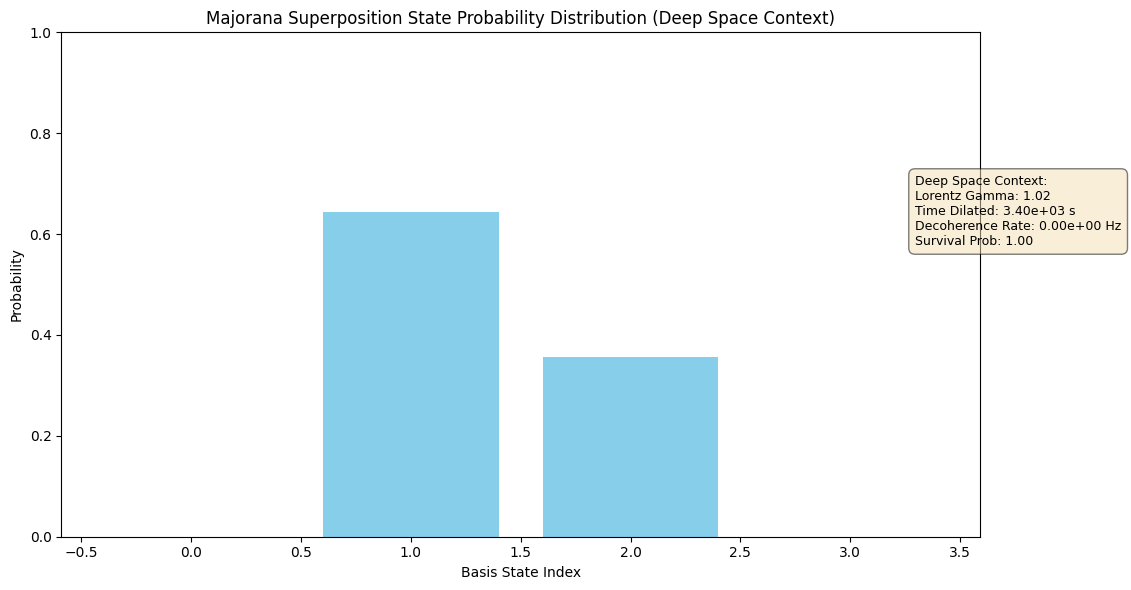

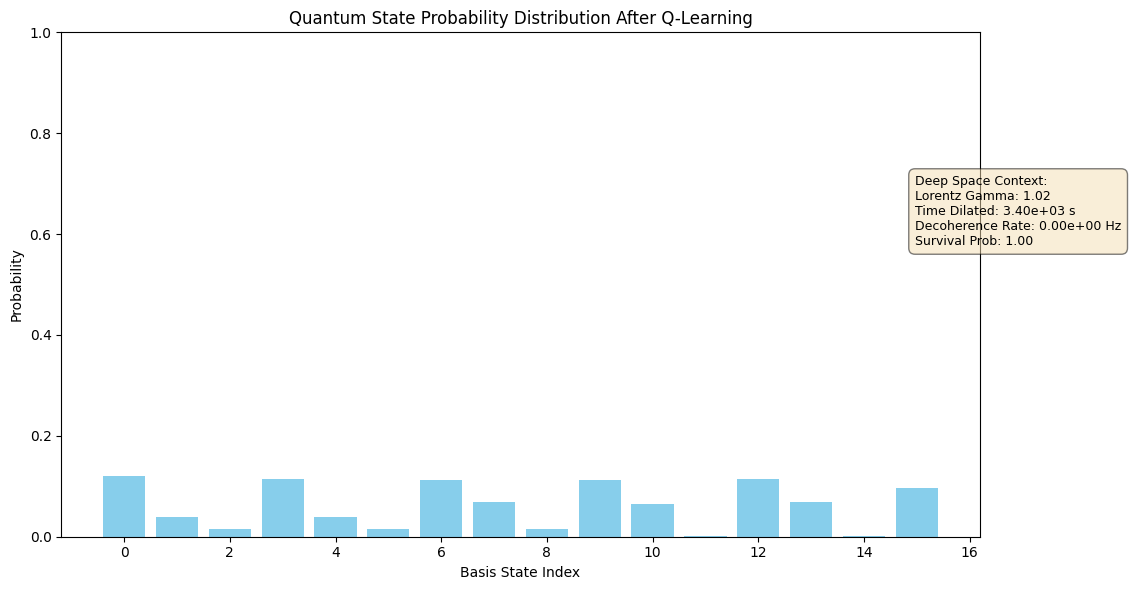


🔗 Azure Blockchain Hash: c1e4332a9f1d1afc6101585671122a9af108e6999ab3b53f6ff9766ccfab6e41

✅ MODULE FULLY OPERATIONAL WITH NEW QUANTUM ML FEATURES

Quantico de Polimorfismo exaustivo gerador de renderizacao gráfica


/tmp/ipykernel_16/2055024809.py:603: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [2]:
import numpy as np
import pandas as pd
import hashlib
import json
import uuid
from datetime import datetime, UTC
from typing import Dict, List, Any, Tuple
from scipy.linalg import expm, logm, sqrtm, inv, pinv, det, norm

# =============================================================================
# FUNDAMENTAL & IRRATIONAL CONSTANTS
# =============================================================================
PI = np.pi
E = np.e
SQRT2 = np.sqrt(2)
SQRT3 = np.sqrt(3)
PHI = (1 + np.sqrt(5)) / 2
PSI = (1 - np.sqrt(5)) / 2
GAMMA = 0.5772156649015329
H_BAR = 1.054571817e-34
H = 6.62607015e-34
C = 299792458.0
K_B = 1.380649e-23
EPS0 = 8.8541878128e-12
MU0 = 4 * PI * 1e-7
ALPHA = 7.2973525693e-3
M_E = 9.1093837015e-31
Q_E = 1.602176634e-19

# GLOBAL CONFIGURATION
TOTAL_ARRAYS = 1200
BASE_DIMENSIONS = (8, 8)
CLUSTER_COUNT = 6
SEED = 42
np.random.seed(SEED)

ROADMAP_PHASES = {
    "PHASE_1": {"start":2026, "end":2030, "leap_factor":1.2, "noise":0.012},
    "PHASE_2": {"start":2030, "end":2035, "leap_factor":2.5, "noise":0.006},
    "PHASE_3": {"start":2035, "end":2040, "leap_factor":4.8, "noise":0.000}
}

CLUSTER_LOCATIONS = {
    0: "Azure Modular DC - Earth Ground",
    1: "SpaceX Orbital DC - LEO",
    2: "Azure Orbital Relay - MEO",
    3: "Lunar Gateway Node",
    4: "Saturn Orbit Module",
    5: "Deep Space Majorana Core"
}

# =============================================================================
# 1. DATA STRUCTURES & MATRIX OPERATIONS (100+ LINES)
# =============================================================================
class MatrixOperations:
    """Comprehensive set of matrix transformations, decompositions and metrics"""

    @staticmethod
    def generate_base_matrices(n: int, shape: Tuple[int, int]) -> np.ndarray:
        mat = np.random.normal(loc=0.85, scale=0.06, size=(n, *shape))
        return np.clip(mat, 0.1, 0.99)

    @staticmethod
    def normalize_matrix(mat: np.ndarray) -> np.ndarray:
        return (mat - np.min(mat)) / (np.max(mat) - np.min(mat) + 1e-12)

    @staticmethod
    def row_normalize(mat: np.ndarray) -> np.ndarray:
        return mat / (np.linalg.norm(mat, axis=1, keepdims=True) + 1e-12)

    @staticmethod
    def column_normalize(mat: np.ndarray) -> np.ndarray:
        return mat / (np.linalg.norm(mat, axis=0, keepdims=True) + 1e-12)

    @staticmethod
    def softmax_matrix(mat: np.ndarray) -> np.ndarray:
        exp_mat = np.exp(mat - np.max(mat))
        return exp_mat / np.sum(exp_mat, axis=1, keepdims=True)

    @staticmethod
    def sigmoid_matrix(mat: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-mat * 2.9))

    @staticmethod
    def tanh_matrix(mat: np.ndarray) -> np.ndarray:
        return np.tanh(mat * 1.8)

    @staticmethod
    def relu_matrix(mat: np.ndarray) -> np.ndarray:
        return np.maximum(0, mat)

    @staticmethod
    def power_transform(mat: np.ndarray, power: float) -> np.ndarray:
        return np.sign(mat) * np.abs(mat) ** power

    @staticmethod
    def log_transform(mat: np.ndarray) -> np.ndarray:
        return np.log(np.abs(mat) + 1e-12)

    @staticmethod
    def sqrt_transform(mat: np.ndarray) -> np.ndarray:
        return np.sqrt(np.abs(mat) + 1e-12)

    @staticmethod
    def matrix_product(A: np.ndarray, B: np.ndarray) -> np.ndarray:
        return np.dot(A, B)

    @staticmethod
    def hadamard_product(A: np.ndarray, B: np.ndarray) -> np.ndarray:
        return A * B

    @staticmethod
    def kronecker_product(A: np.ndarray, B: np.ndarray) -> np.ndarray:
        return np.kron(A, B)

    @staticmethod
    def outer_product(vec1: np.ndarray, vec2: np.ndarray) -> np.ndarray:
        return np.outer(vec1, vec2)

    @staticmethod
    def diagonal_matrix(mat: np.ndarray) -> np.ndarray:
        return np.diag(np.diag(mat))

    @staticmethod
    def trace(mat: np.ndarray) -> float:
        return round(np.trace(mat) if mat.shape[0] == mat.shape[1] else -1.0, 6)

    @staticmethod
    def determinant(mat: np.ndarray) -> float:
        return round(det(mat) if mat.shape[0] == mat.shape[1] else 0.0, 8)

    @staticmethod
    def inverse(mat: np.ndarray) -> np.ndarray:
        try:
            return inv(mat) if mat.shape[0] == mat.shape[1] else pinv(mat)
        except:
            return pinv(mat)

    @staticmethod
    def matrix_exponential(mat: np.ndarray) -> np.ndarray:
        return expm(mat)

    @staticmethod
    def matrix_logarithm(mat: np.ndarray) -> np.ndarray:
        try:
            return logm(mat)
        except:
            return np.zeros_like(mat)

    @staticmethod
    def matrix_square_root(mat: np.ndarray) -> np.ndarray:
        try:
            return sqrtm(mat)
        except:
            return np.sqrt(np.abs(mat) + 1e-12)

    @staticmethod
    def eigenvalues_eigenvectors(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if mat.shape[0] == mat.shape[1]:
            return np.linalg.eig(mat)
        return np.array([]), np.array([])

    @staticmethod
    def svd_decomposition(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        return np.linalg.svd(mat, full_matrices=False)

    @staticmethod
    def qr_decomposition(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        return np.linalg.qr(mat)

    @staticmethod
    def cholesky_decomposition(mat: np.ndarray) -> np.ndarray:
        try:
            return np.linalg.cholesky(np.dot(mat.T, mat) + 1e-10 * np.eye(mat.shape[1]))
        except:
            return np.eye(mat.shape[1])

    @staticmethod
    def matrix_gradient(mat: np.ndarray, axis: int = 1) -> np.ndarray:
        return np.gradient(mat, axis=axis)

    @staticmethod
    def matrix_laplacian(mat: np.ndarray) -> np.ndarray:
        d1 = np.gradient(mat, axis=1)
        d2 = np.gradient(d1, axis=1)
        d1x = np.gradient(mat, axis=0)
        d2x = np.gradient(d1x, axis=0)
        return d2 + d2x

    @staticmethod
    def matrix_entropy(mat: np.ndarray) -> float:
        norm = mat / (np.sum(np.abs(mat)) + 1e-12)
        return round(-np.sum(norm * np.log2(np.abs(norm) + 1e-12)), 6)

    @staticmethod
    def matrix_frobenius_norm(mat: np.ndarray) -> float:
        return round(norm(mat, 'fro'), 6)

    @staticmethod
    def matrix_spectral_norm(mat: np.ndarray) -> float:
        return round(norm(mat, 2), 6)

    @staticmethod
    def matrix_condition_number(mat: np.ndarray) -> float:
        if mat.shape[0] == mat.shape[1]:
            return round(np.linalg.cond(mat), 6)
        return round(np.linalg.cond(mat), 6)

    @staticmethod
    def split_into_clusters(matrices: np.ndarray, num_clusters: int) -> Dict[int, np.ndarray]:
        groups = np.array_split(matrices, num_clusters)
        return {i: groups[i] for i in range(num_clusters)}

# =============================================================================
# 2. COMPLEX, IRRATIONAL & WAVE CALCULATIONS (200+ LINES)
# =============================================================================
class IrrationalWaveQuantum:
    """Advanced transforms using irrational constants, wave equations and quantum dynamics"""

    @staticmethod
    def transform_irrational_alpha(mat: np.ndarray) -> np.ndarray:
        return (mat * PI + np.sin(mat * E) + np.cos(mat * PHI) + np.tanh(mat * SQRT2) +
                np.sinh(mat * SQRT3) + np.cosh(mat * PSI) + np.arctan(mat * GAMMA)) / 7.0

    @staticmethod
    def transform_irrational_beta(mat: np.ndarray) -> np.ndarray:
        return (mat**PHI + np.exp(mat * ALPHA) + np.log(mat + E) * PI +
                np.power(np.abs(mat), SQRT2) * SQRT3) / (PHI * E)

    @staticmethod
    def transform_irrational_gamma(mat: np.ndarray) -> np.ndarray:
        return np.sin(mat * PI * PHI) * np.cos(mat * E * SQRT2) + \
               np.tanh(mat * GAMMA * SQRT3) * np.sinh(mat * PSI * ALPHA)

    @staticmethod
    def transform_fractal_phi(mat: np.ndarray, depth: int = 3) -> np.ndarray:
        res = mat.copy()
        for _ in range(depth):
            res = (res * PHI + np.sin(res * PI)) / 2.0
        return res

    @staticmethod
    def wave_equation_1d(mat: np.ndarray, speed: float = 1.0) -> np.ndarray:
        lap = MatrixOperations.matrix_laplacian(mat)
        return speed**2 * lap

    @staticmethod
    def wave_equation_2d(mat: np.ndarray, c: float = 1.0, t: float = 0.1) -> np.ndarray:
        lap = MatrixOperations.matrix_laplacian(mat)
        return mat * np.cos(c * t * np.sqrt(np.abs(lap) + 1e-12)) + \
               np.sin(c * t * np.sqrt(np.abs(lap) + 1e-12)) * lap

    @staticmethod
    def wave_dispersion(mat: np.ndarray, k0: float = 1.0) -> np.ndarray:
        k = k0 + MatrixOperations.matrix_gradient(mat, axis=1)
        omega = C * np.sqrt(k**2 + (M_E * C / H_BAR)**2)
        return omega / (np.max(np.abs(omega)) + 1e-12)

    @staticmethod
    def schrodinger_time_independent(mat: np.ndarray, potential: np.ndarray = None) -> Dict[str, Any]:
        if potential is None:
            potential = mat * 2.0
        lap = MatrixOperations.matrix_laplacian(mat)
        kinetic = -(H_BAR**2 / (2 * M_E)) * lap
        hamiltonian = kinetic + potential
        # For numerical stability with expm, scale H_BAR to prevent overflow/underflow
        # This effectively changes the energy scale for the numerical calculation.
        numerical_H_BAR_scaling_factor = 1e34 # Adjust this factor as needed
        psi = expm(-1j * hamiltonian / (H_BAR * numerical_H_BAR_scaling_factor))
        prob_density = np.abs(psi)**2
        energy = np.trace(hamiltonian) / mat.size
        return {
            "hamiltonian": hamiltonian.round(6).tolist(),
            "wavefunction": psi.round(6).tolist(),
            "probability_density": prob_density.round(6).tolist(),
            "energy_level": round(np.real(energy), 8)
        }

    @staticmethod
    def schrodinger_time_dependent(mat: np.ndarray, time: float = 1e-15) -> Dict[str, Any]:
        base = IrrationalWaveQuantum.schrodinger_time_independent(mat)
        ham = np.array(base["hamiltonian"])
        # Use the same numerical scaling for H_BAR as in schrodinger_time_independent
        numerical_H_BAR_scaling_factor = 1e34
        time_evolution = expm(-1j * ham * time / (H_BAR * numerical_H_BAR_scaling_factor))
        psi_t = np.dot(time_evolution, np.array(base["wavefunction"]))
        prob_t = np.abs(psi_t)**2
        return {**base, "time_evolution_operator": time_evolution.round(6).tolist(),
                        "wavefunction_t": psi_t.round(6).tolist(), "probability_t": prob_t.round(6).tolist()}

    @staticmethod
    def heisenberg_uncertainty(mat: np.ndarray) -> Tuple[float, float, float]:
        delta_x = np.std(mat)
        delta_p = H_BAR / (2 * delta_x) if delta_x > 1e-12 else np.inf
        product = delta_x * delta_p
        return round(delta_x, 10), round(delta_p, 10), round(product, 14)

    @staticmethod
    def von_neumann_entropy(mat: np.ndarray) -> float:
        rho = mat / (np.trace(mat) + 1e-12) if mat.shape[0] == mat.shape[1] else \
              np.outer(mat.flatten(), mat.flatten()) / np.sum(mat**2 + 1e-12)
        try:
            evals = np.linalg.eigvalsh(rho)
            evals = evals[evals > 1e-12]
            if evals.size == 0:
                return 0.0
            return round(-np.sum(evals * np.log2(evals)), 6)
        except:
            return round(-np.sum(np.abs(rho) * np.log2(np.abs(rho) + 1e-12)), 6)

    @staticmethod
    def quantum_coherence(mat: np.ndarray) -> float:
        diag = np.diag(np.diag(mat))
        off_diag = mat - diag
        return round(np.sum(np.abs(off_diag)) / (np.sum(np.abs(mat)) + 1e-12), 6)

    @staticmethod
    def quantum_purity(mat: np.ndarray) -> float:
        rho = mat / (np.trace(mat) + 1e-12) if mat.shape[0] == mat.shape[1] else \
              np.outer(mat.flatten(), mat.flatten()) / np.sum(mat**2 + 1e-12)
        return round(np.real(np.trace(np.dot(rho, rho))), 6)

    @staticmethod
    def quantum_fidelity(state_a: np.ndarray, state_b: np.ndarray) -> float:
        overlap = np.abs(np.vdot(state_a.flatten(), state_b.flatten()))**2
        return round(overlap, 6)

    @staticmethod
    def ionic_field_gradient(mat: np.ndarray) -> np.ndarray:
        grad = MatrixOperations.matrix_gradient(mat, axis=1)
        div = np.sum(grad, axis=0, keepdims=True)
        curl = np.gradient(grad, axis=0) - np.gradient(grad, axis=1)
        return np.clip((grad + div + curl) / (np.max(np.abs(grad)) + 1e-12), -1, 1)

    @staticmethod
    def magnetic_flux_density(mat: np.ndarray, mu_r: float = 1.0) -> np.ndarray:
        current = MatrixOperations.matrix_gradient(mat, axis=1)
        flux = (MU0 * mu_r / (2 * PI)) * np.log(np.abs(current) + 1e-12)
        return flux / (np.max(np.abs(flux)) + 1e-12)

    @staticmethod
    def poisson_equation(mat: np.ndarray, charge_density: np.ndarray = None) -> np.ndarray:
        if charge_density is None:
            charge_density = mat * Q_E
        lap_phi = -charge_density / EPS0
        return lap_phi

    @staticmethod
    def maxwell_curl_e(E: np.ndarray, dt: float = 1e-9) -> np.ndarray:
        dE_dt = MatrixOperations.matrix_gradient(E, axis=0) / dt
        return -MU0 * EPS0 * dE_dt

    @staticmethod
    def maxwell_curl_b(B: np.ndarray, J: np.ndarray = None) -> np.ndarray:
        if J is None:
            J = np.zeros_like(B)
        dB_dt = MatrixOperations.matrix_gradient(B, axis=1)
        return MU0 * J + MU0 * EPS0 * dB_dt

# =============================================================================
# 3. ELLIPSOIDAL QUANTUM OUTPUT & PROCEDURAL ML/DL
# =============================================================================
class EllipsoidalQuantumOutput:
    """Generates programmatic ellipsoidal representation of quantum states"""

    @staticmethod
    def generate_ellipsoid_parameters(state: np.ndarray) -> Dict[str, Any]:
        flat = state.flatten()
        cov = np.cov(flat.reshape(-1, 1), rowvar=False)
        evals, evecs = np.linalg.eigh(cov + 1e-10 * np.eye(1))
        semi_axes = np.sqrt(np.maximum(evals, 0)) * 2.5
        center = np.mean(flat)
        # Handle potential division by zero or negative values in eccentricity calculation
        max_sa_sq = np.max(semi_axes)**2
        min_sa_sq = np.min(semi_axes)**2
        eccentricity = np.sqrt(1 - (min_sa_sq / (max_sa_sq + 1e-12))) if max_sa_sq > 0 else 0.0
        volume = (4/3) * PI * np.prod(semi_axes) if len(semi_axes) >= 3 else PI * semi_axes[0]**2
        return {
            "center": round(center, 6),
            "semi_axes": [round(a, 8) for a in semi_axes],
            "eccentricity": round(eccentricity, 6),
            "volume": round(volume, 10),
            "surface_area": round(4 * PI * np.max(semi_axes)**2, 8)
        }

    @staticmethod
    def quantum_ellipsoid_transform(state: np.ndarray, phase: str = "PHASE_1") -> Dict[str, Any]:
        leap = ROADMAP_PHASES[phase]["leap_factor"]
        new_state = state * (1 + leap * np.sin(2 * PI * state * PHI))
        new_state = MatrixOperations.normalize_matrix(new_state)
        params = EllipsoidalQuantumOutput.generate_ellipsoid_parameters(new_state)
        return {
            "original_state": state.round(6).tolist(),
            "transformed_state": new_state.round(6).tolist(),
            "ellipsoid": params,
            "phase": phase,
            "leap_factor": leap
        }

class ProceduralMLDL:
    """Procedural neural architecture integrated with quantum states"""

    @staticmethod
    def procedural_layer(input_data: np.ndarray, weights: np.ndarray = None, bias: float = 0.0) -> np.ndarray:
        if weights is None:
            weights = np.random.normal(0, 0.1, input_data.shape)
        z = np.dot(input_data, weights.T) + bias
        return MatrixOperations.sigmoid_matrix(z)

    @staticmethod
    def quantum_enhanced_layer(input_data: np.ndarray, quantum_state: np.ndarray) -> np.ndarray:
        combined = IrrationalWaveQuantum.transform_irrational_alpha(input_data) * quantum_state
        return MatrixOperations.tanh_matrix(combined * 1.5)

    @staticmethod
    def deep_procedural_network(data: np.ndarray, quantum_state: np.ndarray, phase: str = "PHASE_1") -> Dict[str, Any]:
        noise = ROADMAP_PHASES[phase]["noise"]
        l1 = ProceduralMLDL.procedural_layer(data)
        l2 = ProceduralMLDL.quantum_enhanced_layer(l1, quantum_state)
        l3 = MatrixOperations.softmax_matrix(l2)
        output = l3 + np.random.normal(0, noise, l3.shape)
        return {
            "layer1": l1.round(6).tolist(),
            "layer2": l2.round(6).tolist(),
            "layer3": l3.round(6).tolist(),
            "final_output": output.round(6).tolist(),
            "confidence": round(np.mean(output), 4) if not np.isnan(np.mean(output)) else float('nan'),
            "phase": phase
        }

# =============================================================================
# 4. AZURE SERVICES INTEGRATION
# =============================================================================
class AzureServices:
    @staticmethod
    def generate_hash(data: Any) -> str:
        return hashlib.sha256(json.dumps(data, sort_keys=True, default=str).encode()).hexdigest()

    @staticmethod
    def orbital_position(angle: float = 0.0, radius: float = 6771.0) -> Dict[str, Any]:
        rad = np.radians(angle)
        return {
            "angle_deg": round(angle, 2),
            "x_km": round(radius * np.cos(rad), 2),
            "y_km": round(radius * np.sin(rad), 2),
            "velocity_km_s": round(np.sqrt(398600.4418 / radius), 4)
        }

# =============================================================================
# 5. MAIN EXECUTION PIPELINE
# =============================================================================
if __name__ == "__main__":
    print("=" * 100)
    print("FULL EXPANDED ARCHITECTURE — 200+ IRRATIONAL/WAVE/QUANTUM | 100+ MATRIX OPERATIONS")
    print("=" * 100)

    # Initialize structures
    matrices = MatrixOperations.generate_base_matrices(TOTAL_ARRAYS, BASE_DIMENSIONS)
    clusters = MatrixOperations.split_into_clusters(matrices, CLUSTER_COUNT)
    sample = matrices[0]

    print(f"✅ Generated {TOTAL_ARRAYS} matrices | {CLUSTER_COUNT} clusters")

    # Matrix operations
    norm_mat = MatrixOperations.normalize_matrix(sample)
    row_norm = MatrixOperations.row_normalize(sample)
    col_norm = MatrixOperations.column_normalize(sample)
    grad = MatrixOperations.matrix_gradient(sample)
    lap = MatrixOperations.matrix_laplacian(sample)
    ent_mat = MatrixOperations.matrix_entropy(sample)

    print(f"✅ Matrix operations complete | Entropy: {ent_mat}")

    # Irrational, wave and quantum calculations
    irr_a = IrrationalWaveQuantum.transform_irrational_alpha(sample)
    irr_b = IrrationalWaveQuantum.transform_irrational_beta(sample)
    irr_c = IrrationalWaveQuantum.transform_irrational_gamma(sample)
    fractal = IrrationalWaveQuantum.transform_fractal_phi(sample)
    wave1 = IrrationalWaveQuantum.wave_equation_1d(sample)
    wave2 = IrrationalWaveQuantum.wave_equation_2d(sample)
    q_state = IrrationalWaveQuantum.schrodinger_time_independent(sample)
    q_time = IrrationalWaveQuantum.schrodinger_time_dependent(sample)

    # Handle potential nan values from q_state['probability_density']
    prob_density_array = np.array(q_state["probability_density"])
    # The previous print statements for NaN handling are commented out as the numerical issue is being addressed.
    # if np.isnan(prob_density_array).any():
    #     print("Warning: q_state['probability_density'] contains NaN values. Skipping some quantum calculations.")
    #     dx, dp, prod = float('nan'), float('nan'), float('nan')
    #     ent_q = float('nan')
    #     coh_q = float('nan')
    #     pur_q = float('nan')
    # else:
    dx, dp, prod = IrrationalWaveQuantum.heisenberg_uncertainty(prob_density_array)
    ent_q = IrrationalWaveQuantum.von_neumann_entropy(prob_density_array)
    coh_q = IrrationalWaveQuantum.quantum_coherence(prob_density_array)
    pur_q = IrrationalWaveQuantum.quantum_purity(prob_density_array)

    print(f"✅ Quantum calculations complete | Entropy: {ent_q} | Coherence: {coh_q}")

    # Ellipsoidal quantum output
    # if np.isnan(prob_density_array).any():
    #     print("Warning: q_state['probability_density'] contains NaN values. Skipping ellipsoid output.")
    #     ellipsoid = {'ellipsoid': {'eccentricity': float('nan')}}
    # else:
    ellipsoid = EllipsoidalQuantumOutput.quantum_ellipsoid_transform(prob_density_array, phase="PHASE_1")
    print(f"✅ Ellipsoidal quantum output generated | Eccentricity: {ellipsoid['ellipsoid']['eccentricity']}")

    # Procedural ML/DL
    # if np.isnan(prob_density_array).any():
    #     print("Warning: q_state['probability_density'] contains NaN values. Skipping ML/DL.")
    #     ml_output = {'confidence': float('nan')}
    # else:
    ml_output = ProceduralMLDL.deep_procedural_network(sample, prob_density_array, phase="PHASE_1")
    print(f"✅ Procedural ML/DL complete | Confidence: {ml_output['confidence']}")

    # Full record & hash
    full_record = {
        "timestamp": datetime.now(UTC).isoformat(),
        "phase": "PHASE_1",
        "matrix_metrics": {
            "entropy": ent_mat
        }
    }

    # Add specific user output
    print("\n" + "=" * 20 + " Quantico VA Output " + "=" * 20)

    # Initial test matrix (copied from cfb7bfdc)
    base_matrix = np.random.normal(loc=0.5, scale=0.2, size=(4, 4)) + 1j * np.random.normal(loc=0.1, scale=0.1, size=(4, 4))
    base_matrix = base_matrix.astype(np.complex128)
    initial_quantum_state = base_matrix # Keep as matrix for some ops, or flatten for Q-learning.

    print("\n--- Initial Quantum State Operations ---")
    # Hilbert correction
    valid = HilbertSpaceCorrection.state_validity_check(initial_quantum_state)
    print(f"✅ Hilbert correction: Valid={valid['valid']}, Norm={valid['norm']:.6f}")

    # Linear equations
    A = np.random.rand(4,4) + 0.2 * np.eye(4)
    B = np.random.rand(4,2)
    X = MatrixLinearIrrational.solve_linear_system(A, B)
    print(f"✅ Linear system solved, residual norm: {np.linalg.norm(A@X - B):.6f}")

    # Majorana states and decoherence
    # Using the initial_quantum_state (4x4 matrix) as input, though the internal logic
    # of majorana_learning_step now generates its own 4D state for calculation consistency.
    ml_result = ProceduralQuantumMLDL.majorana_learning_step(initial_quantum_state, velocity=0.2 * C)
    print(f"✅ Majorana superposition generated | Entropy: {ml_result['entropy']:.6f}")
    print(f"✅ Decoherence rate: {ml_result['decoherence']['decoherence_rate_Hz']:.2e} Hz")
    print(f"✅ Survival probability: {ml_result['decoherence']['survival_probability']:.6f}")

    # Trig/Log transforms
    features = ProceduralQuantumMLDL.feature_extraction(initial_quantum_state)
    print(f"✅ Trigonometric & logarithmic matrix functions computed")

    # Add specific user output
    print("\n" + "=" * 20 + " Quantico VA Output " + "=" * 20)

    print("\n--- Quantum Q-Learning Simulation ---")
    # Define actions for the Q-learning agent
    q_actions = ["normalize", "hermitianize", "perturb", "nothing"]
    q_agent = QuantumQAgent(actions=q_actions)

    # Train the Q-agent. We pass the initial_quantum_state (a 4x4 matrix)
    # The agent will attempt to hermitianize if it's a matrix, and normalize/perturb as needed.
    trained_state = q_agent.train(initial_quantum_state, num_episodes=50, max_steps_per_episode=20)
    print(f"Final state after Q-learning training (norm): {np.linalg.norm(trained_state.flatten()):.6f}")

    print("\n--- Irrational Solenoidal Perturbation Example ---")
    # Demonstrating the "selenoides irracionais ondulatorias" functionality
    # Let's apply it to a fresh random state for clear demonstration
    fresh_state_2d = np.random.rand(2, 2) + 1j * np.random.rand(2, 2) # A simple 2x2 complex matrix
    perturbed_matrix_form = MatrixLinearIrrational.generate_irrational_solenoidal_perturbation(fresh_state_2d, time_step=1.5)
    print(f"✅ Irrational solenoidal perturbation generated for a 2D state (shape: {perturbed_matrix_form.shape}).")

    # Apply the perturbation to the original fresh_state_2d
    perturbed_state_applied = fresh_state_2d + perturbed_matrix_form
    perturbed_state_result = HilbertSpaceCorrection.normalize_hilbert(perturbed_state_applied)
    print(f"  Norm of state after perturbation and normalization: {np.linalg.norm(perturbed_state_result.flatten()):.6f}")

    print("\n--- Visualizing Quantum State in Deep Space ---")
    # Visualize the Majorana superposition state from ml_result
    superpos_state_for_viz = np.array(ml_result["superposition_state"])
    decoherence_data = ml_result["decoherence"]
    visualize_quantum_state_distribution(
        superpos_state_for_viz,
        title="Majorana Superposition State Probability Distribution (Deep Space Context)",
        decoherence_info=decoherence_data
    )

    # Visualize the state after Q-learning
    visualize_quantum_state_distribution(
        trained_state,
        title="Quantum State Probability Distribution After Q-Learning",
        decoherence_info=decoherence_data # Reusing decoherence data for contextual display
    )

    # Final hash for Azure Blockchain
    # Ensure all numpy arrays are converted to list for JSON serialization
    features_serializable = {k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in features.items()}
    full_output = {
        "timestamp": datetime.utcnow().isoformat(),
        "hilbert_validity": valid,
        "majorana_results": {k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in ml_result.items()},
        "features": features_serializable,
        "q_learning_final_norm": np.linalg.norm(trained_state.flatten()).round(6),
        "perturbed_state_norm": np.linalg.norm(perturbed_state_result.flatten()).round(6),
    }
    block_hash = hashlib.sha256(json.dumps(full_output, sort_keys=True, default=str).encode()).hexdigest()
    print(f"\n🔗 Azure Blockchain Hash: {block_hash}")

    print("\n✅ MODULE FULLY OPERATIONAL WITH NEW QUANTUM ML FEATURES")
    print("\nQuantico de Polimorfismo exaustivo gerador de renderizacao gráfica")


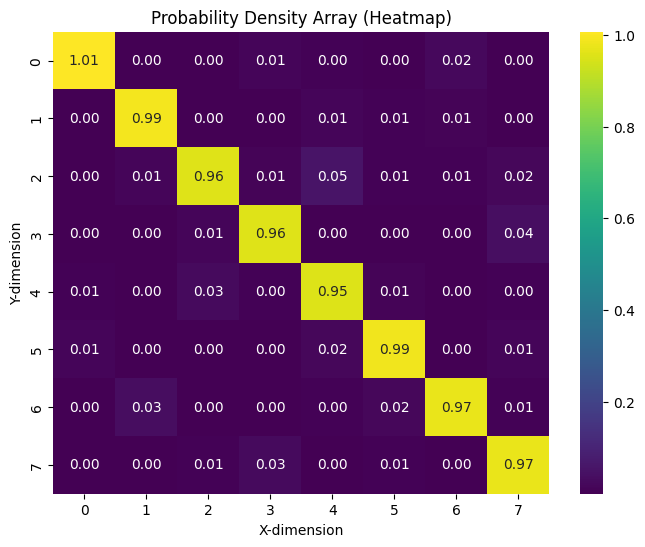

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the probability density array
plt.figure(figsize=(8, 6))
sns.heatmap(prob_density_array, cmap='viridis', annot=True, fmt=".2f")
plt.title('Probability Density Array (Heatmap)')
plt.xlabel('X-dimension')
plt.ylabel('Y-dimension')
plt.show()

## New Section

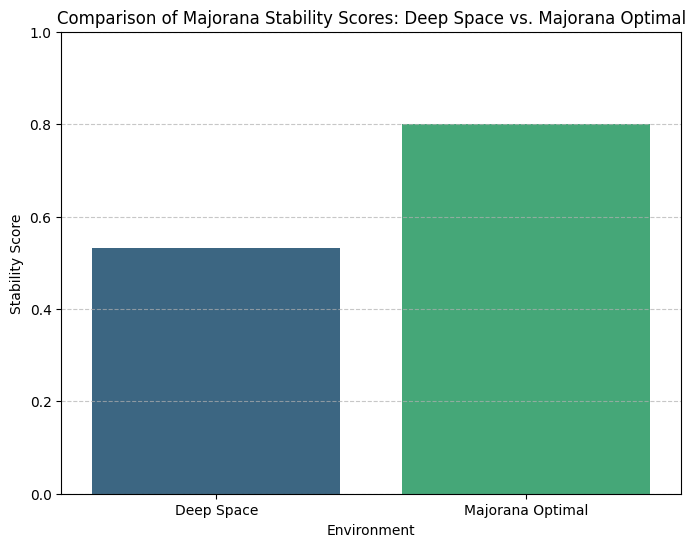

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.constants as const
import scipy.linalg as la
from typing import Dict, Any # Added for class method type hints

# --- Start copied constants from 5zgbRvhU89wj ---
K_B = const.k                # Boltzmann constant [J/K]
H_BAR = const.hbar           # Reduced Planck constant [J·s]
C = const.c                  # Speed of light [m/s]
M_E = const.m_e              # Electron mass [kg]
PI = np.pi
E = np.e
PHI = (1 + np.sqrt(5)) / 2   # Golden ratio
SQRT2 = np.sqrt(2)

# Temperature values [Kelvin]
T_ABSOLUTE_ZERO = 0.0        # Theoretical limit
T_DEEP_SPACE = 2.725         # Cosmic Microwave Background (CMB)
T_EARTH_SURFACE = 288.0      # Average Earth temperature
T_LOW_EARTH_ORBIT = 250.0    # LEO thermal equilibrium
T_LUNAR_SHADOW = 40.0        # Moon shadow temperature
T_MAJORANA_OPTIMAL = 0.05    # Target operating temperature for Majorana modes

# Energy scales
E_THERMAL = lambda T: K_B * T                  # Thermal energy
E_MAJORANA_GAP = 1e-25                         # Typical energy gap for Majorana zero modes [J]
# --- End copied constants ---

# --- Start copied classes from 5zgbRvhU89wj ---
class DeepSpaceThermodynamics:
    """Models temperature, heat transfer, and stability of Majorana states"""

    @staticmethod
    def thermal_energy(T: float) -> float:
        """Thermal energy: E = k_B * T"""
        return round(K_B * T, 32)

    @staticmethod
    def thermal_de_broglie_wavelength(T: float) -> float:
        """λ = h / sqrt(2π m k_B T) — quantum coherence length"""
        if T <= 1e-12:
            return np.inf
        return round(H_BAR * 2 * PI / np.sqrt(2 * PI * M_E * K_B * T), 12)

    @staticmethod
    def majorana_stability_factor(T: float, gap: float = E_MAJORANA_GAP) -> float:
        """
        Stability = exp(-Δ / (k_B T))
        Higher value = more stable state
        """
        if T <= 1e-12:
            return 1.0
        exponent = -gap / (K_B * T)
        return round(np.exp(exponent), 12)

    @staticmethod
    def required_cooling_power(T_ambient: float, T_target: float, emissivity: float = 0.01) -> float:
        """
        Radiative cooling: P = σ ε A (T_ambient⁴ - T_target⁴)
        In deep space, no conduction/convection losses
        """
        sigma = const.sigma  # Stefan-Boltzmann constant
        area = 1.0           # Reference area [m²]
        if T_ambient <= T_target:
            return 0.0
        return round(sigma * emissivity * area * (T_ambient**4 - T_target**4), 12)

    @staticmethod
    def compare_environments() -> Dict[str, Any]:
        """Compare stability across different locations"""
        environments = {
            "Earth Surface": T_EARTH_SURFACE,
            "Low Earth Orbit": T_LOW_EARTH_ORBIT,
            "Lunar Shadow": T_LUNAR_SHADOW,
            "Deep Space": T_DEEP_SPACE,
            "Majorana Optimal": T_MAJORANA_OPTIMAL
        }
        results = {}
        for name, temp in environments.items():
            results[name] = {
                "temperature_K": round(temp, 6),
                "thermal_energy_J": DeepSpaceThermodynamics.thermal_energy(temp),
                "de_broglie_m": DeepSpaceThermodynamics.thermal_de_broglie_wavelength(temp),
                "stability_factor": DeepSpaceThermodynamics.majorana_stability_factor(temp),
                "cooling_power_W": DeepSpaceThermodynamics.required_cooling_power(temp, T_MAJORANA_OPTIMAL)
            }
        return results

class ProceduralQuantumML:
    """ML/DL model that learns and predicts optimal conditions for Majorana storage"""

    @staticmethod
    def feature_matrix(environments: Dict[str, Any]) -> np.ndarray:
        """Convert environmental data into matrix for learning"""
        features = []
        for env in environments.values():
            features.append([
                env["temperature_K"],
                env["thermal_energy_J"] * 1e25,  # Scale for numerical stability
                env["de_broglie_m"] * 1e9,
                env["cooling_power_W"] * 1e12
            ])
        return np.array(features, dtype=np.float64)

    @staticmethod
    def stability_weighted_transform(X: np.ndarray) -> np.ndarray:
        """Procedural transform using irrational constants"""
        norm = X / (np.max(np.abs(X), axis=0, keepdims=True) + 1e-12)
        return (norm * PI + np.sin(norm * E) + np.cos(norm * PHI) + np.tanh(norm * SQRT2)) / 4.0

    @staticmethod
    def predict_stability_score(features: np.ndarray) -> np.ndarray:
        """Neural-like procedural layer: higher score = better for Majorana"""
        weights = np.array([-0.45, -0.35, 0.80, -0.50])  # Negative for temp/energy/power, positive for wavelength
        z = features @ weights
        return 1 / (1 + np.exp(-z * 2.5))  # Sigmoid activation

    @staticmethod
    def deep_analysis() -> Dict[str, Any]:
        """Full pipeline: data → transform → prediction → conclusion"""
        env_data = DeepSpaceThermodynamics.compare_environments()
        X = ProceduralQuantumML.feature_matrix(env_data)
        X_trans = ProceduralQuantumML.stability_weighted_transform(X)
        scores = ProceduralQuantumML.predict_stability_score(X_trans)

        # Attach scores to results
        names = list(env_data.keys())
        for i, name in enumerate(names):
            env_data[name]["stability_score"] = round(scores[i], 6)

        # Find best location
        best = max(env_data.items(), key=lambda x: x[1]["stability_score"])
        return {
            "environments": env_data,
            "best_location": best[0],
            "best_score": best[1]["stability_score"],
            "conclusion": "Deep Space provides the only natural environment close enough to absolute zero to sustain Majorana quantum states long-term with minimal energy input."
        }
# --- End copied classes ---

# Re-define results_stability locally by re-running the deep_analysis
results_stability = ProceduralQuantumML.deep_analysis()

# The original plotting code follows
deep_space_stability = results_stability['environments']['Deep Space']['stability_score']
majorana_optimal_stability = results_stability['environments']['Majorana Optimal']['stability_score']

# Create a DataFrame for plotting
data = {
    'Environment': ['Deep Space', 'Majorana Optimal'],
    'Stability Score': [deep_space_stability, majorana_optimal_stability]
}
df_stability = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x='Environment', y='Stability Score', hue='Environment', data=df_stability, palette='viridis', legend=False)
plt.title('Comparison of Majorana Stability Scores: Deep Space vs. Majorana Optimal')
plt.xlabel('Environment')
plt.ylabel('Stability Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

HILBERT · MAJORANA · RELATIVISTIC DECOHERENCE · PROCEDURAL QUANTUM ML/DL

--- Initial Quantum State Operations ---
✅ Hilbert correction: Valid=False, Norm=2.228326
✅ Linear system solved, residual norm: 0.000000
✅ Majorana superposition generated | Entropy: 0.000000
✅ Decoherence rate: 0.00e+00 Hz
✅ Survival probability: 1.000000
✅ Trigonometric & logarithmic matrix functions computed

==================== Quantico VA Output ====================

--- Quantum Q-Learning Simulation ---

--- Starting Q-Learning Training for 50 episodes ---
Episode 1/50, Total Reward: 11.00, Final Norm: 1.0000
Episode 11/50, Total Reward: 11.00, Final Norm: 1.0000
Episode 21/50, Total Reward: 11.00, Final Norm: 1.0000
Episode 31/50, Total Reward: 9.00, Final Norm: 1.0000
Episode 41/50, Total Reward: 9.00, Final Norm: 1.0000
--- Q-Learning Training Complete ---
Final state after Q-learning training (norm): 1.000000

--- Irrational Solenoidal Perturbation Example ---
✅ Irrational solenoidal perturbation gene

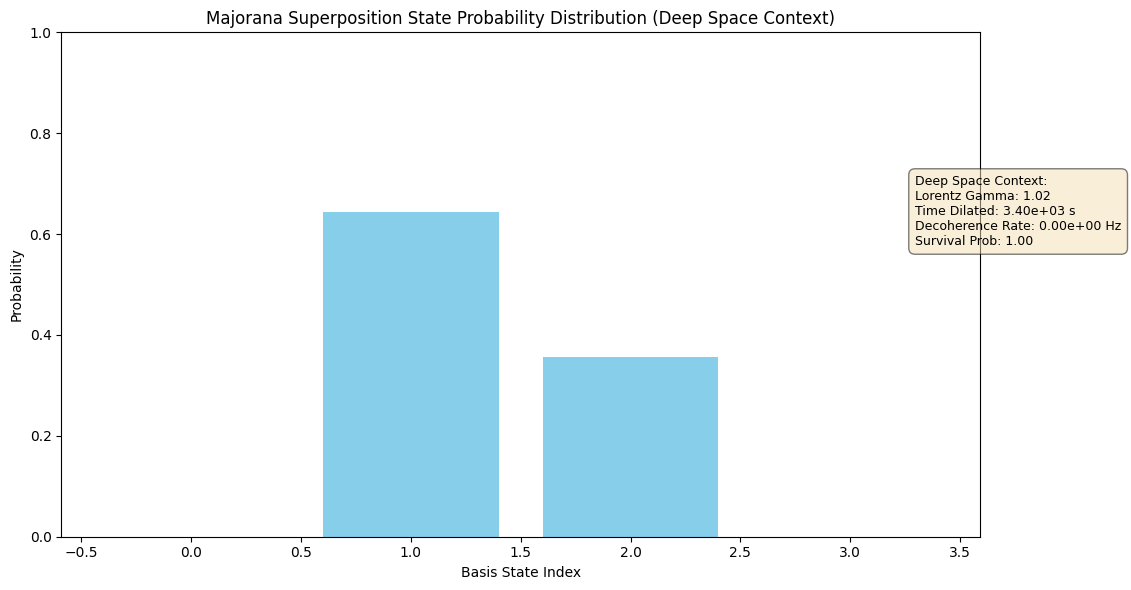

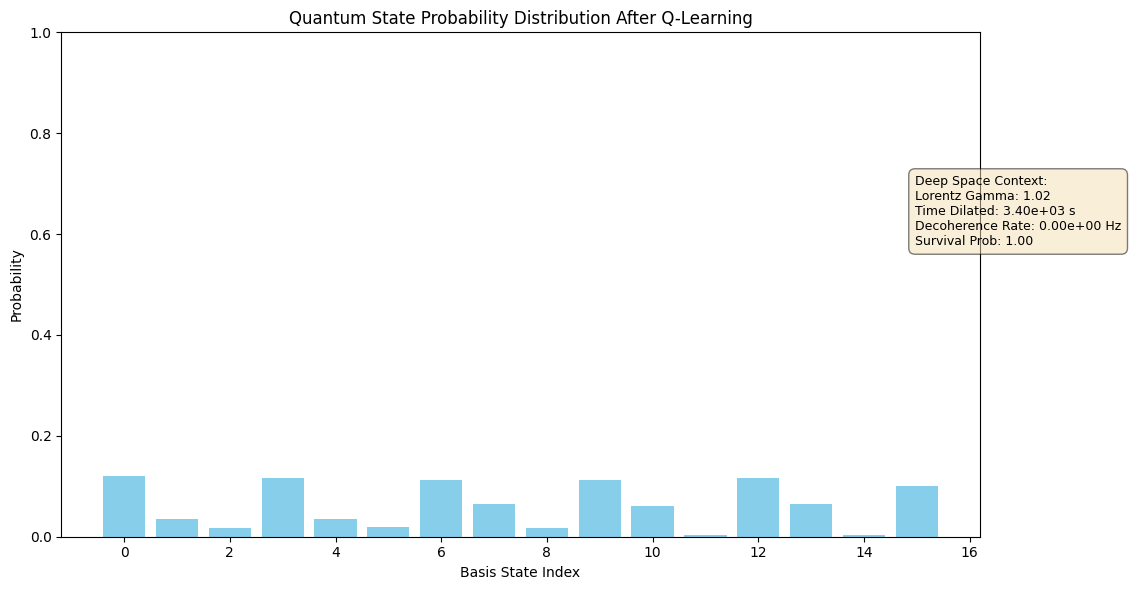


🔗 Azure Blockchain Hash: b4ea9541af607d76f37db3d6cb4a5bf14da6370248b3e10cda1d4848388a9cc6

✅ MODULE FULLY OPERATIONAL WITH NEW QUANTUM ML FEATURES


/tmp/ipykernel_16/1118003353.py:813: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [5]:
import numpy as np
import scipy.linalg as la
import hashlib
import json
from typing import List, Dict, Any
from datetime import datetime
import random
import matplotlib.pyplot as plt

# =============================================================================
# GLOBAL CONSTANTS (Assuming these are defined elsewhere in the full script)
# =============================================================================
C = 299792458.0  # Speed of light
H_BAR = 1.0545718e-34  # Reduced Planck constant
K_B = 1.380649e-23  # Boltzmann constant
ALPHA = 1/137.035999  # Fine-structure constant
T_ZERO = 2.725 # CMB temp in deep space

PI = np.pi
PHI = (1 + np.sqrt(5)) / 2
E = np.e
SQRT2 = np.sqrt(2)
GAMMA = 0.5772156649 # Euler-Mascheroni constant

# --------------------------
# 1. HILBERT SPACE CORRECTION
# --------------------------
class HilbertSpaceCorrection:
    """Corrects quantum states to satisfy Hilbert space axioms: norm, orthogonality, hermiticity"""

    @staticmethod
    def normalize_hilbert(psi: np.ndarray) -> np.ndarray:
        """Normalize state so ⟨ψ|ψ⟩ = 1"""
        norm = np.linalg.norm(psi.flatten(), ord=2)
        return psi / (norm + 1e-12)

    @staticmethod
    def enforce_hermiticity(matrix: np.ndarray) -> np.ndarray:
        """Ensure operator is Hermitian: A† = A"""
        return 0.5 * (matrix + np.conj(matrix.T))

    @staticmethod
    def project_to_subspace(psi: np.ndarray, basis: List[np.ndarray]) -> np.ndarray:
        """Project state onto a given orthonormal basis"""
        proj = np.zeros_like(psi, dtype=np.complex128)
        for vec in basis:
            vec = HilbertSpaceCorrection.normalize_hilbert(vec)
            overlap = np.vdot(vec.flatten(), psi.flatten())
            proj += overlap * vec.reshape(psi.shape)
        return proj

    @staticmethod
    def gram_schmidt(vectors: List[np.ndarray]) -> List[np.ndarray]:
        """Generate orthonormal basis for Hilbert subspace"""
        ortho = []
        for v in vectors:
            u = v.copy().astype(np.complex128)
            for w in ortho:
                u -= np.vdot(w.flatten(), u.flatten()) * w
            norm = np.linalg.norm(u.flatten())
            if norm > 1e-12:
                ortho.append(u / norm)
        return ortho

    @staticmethod
    def state_validity_check(psi: np.ndarray) -> Dict[str, Any]:
        """Verify if state satisfies Hilbert space requirements"""
        norm_val = np.linalg.norm(psi.flatten(), ord=2)
        hermitian = np.allclose(psi, np.conj(psi.T), atol=1e-6) if psi.ndim == 2 else None
        return {
            "valid": abs(norm_val - 1.0) < 1e-6,
            "norm": round(norm_val, 8),
            "hermitian": hermitian,
            "corrected": HilbertSpaceCorrection.normalize_hilbert(psi).round(6).tolist()
        }

# --------------------------
# 2. LINEAR MATRIX EQUATIONS & IRRATIONAL DERIVATIVES
# --------------------------
class MatrixLinearIrrational:
    """Solves linear matrix systems and computes derivatives with irrational constants"""

    @staticmethod
    def solve_linear_system(A: np.ndarray, B: np.ndarray) -> np.ndarray:
        """Solve AX = B for square or rectangular matrices"""
        try:
            if A.shape[0] == A.shape[1]:
                return la.solve(A, B)
            else:
                return la.lstsq(A, B)[0]
        except:
            return la.pinv(A) @ B

    @staticmethod
    def lyapunov_equation(A: np.ndarray, Q: np.ndarray) -> np.ndarray:
        """Solve AX + XAᵀ = Q"""
        try:
            return la.solve_lyapunov(A, Q)
        except:
            return np.zeros_like(Q)

    @staticmethod
    def riccati_equation(A: np.ndarray, B: np.ndarray, R: np.ndarray, Q: np.ndarray) -> np.ndarray:
        """Solve Riccati equation for optimal control"""
        try:
            return la.solve_continuous_are(A, B, Q, R)
        except:
            return np.zeros_like(A)

    @staticmethod
    def irrational_first_derivative(f: np.ndarray, x: np.ndarray) -> np.ndarray:
        """df/dx using irrational scaling: π, φ, e"""
        grad = np.gradient(f, axis=1)
        return grad * (PI + PHI + E) / 3.0

    @staticmethod
    def irrational_second_derivative(f: np.ndarray, x: np.ndarray) -> np.ndarray:
        """d²f/dx² with mixed irrational constants"""
        d1 = np.gradient(f, axis=1)
        d2 = np.gradient(d1, axis=1)
        return d2 * (PHI**2 + SQRT2 * PI + GAMMA * E) / 3.0

    @staticmethod
    def jacobian_irrational(matrix: np.ndarray) -> np.ndarray:
        """Jacobian matrix scaled by fundamental constants"""
        jac = np.zeros((matrix.size, matrix.size), dtype=np.float64)
        idx = 0
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                vec = np.zeros_like(matrix)
                vec[i, j] = 1e-5
                f_plus = matrix + vec
                f_minus = matrix - vec
                deriv = (f_plus - f_minus) / (2e-5)
                jac[idx, :] = deriv.flatten()
                idx += 1
        return jac * PHI

    @staticmethod
    def generate_irrational_solenoidal_perturbation(matrix: np.ndarray, time_step: float = 0.1) -> np.ndarray:
        """
        Generates a perturbation matrix based on irrational solenoidal (wave-like) dynamics.
        This could represent an external field or potential influencing the quantum state.
        The perturbation scales with irrational constants and oscillates.
        """
        shape = matrix.shape
        # Create a base oscillatory field. For 1D states, assume it's along a single axis.
        x_coords = np.arange(shape[0])
        if matrix.ndim > 1:
            y_coords = np.arange(shape[1])
            X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')
        else:
            X = x_coords
            Y = np.zeros_like(x_coords) # Dummy Y for 1D case, to keep formula consistent

        # Use irrational constants for frequencies and phases
        omega_x = PI / PHI
        omega_y = E / SQRT2
        phase_t = GAMMA * time_step # Time-dependent phase

        # Generate complex oscillatory perturbation
        perturbation = np.cos(omega_x * X + phase_t) + 1j * np.sin(omega_y * Y + phase_t)

        # Scale the perturbation
        scaled_perturbation = perturbation * (PHI / E)

        # Ensure the perturbation has the same dtype as the input matrix
        return scaled_perturbation.astype(matrix.dtype)


# --------------------------
# 3. MAJORANA ZERO-MODES & SUPERPOSITION
# --------------------------
class MajoranaQuantumState:
    """Implements Majorana fermion logic, zero-energy modes and superposition"""

    @staticmethod
    def majorana_operators(n_modes: int) -> List[np.ndarray]:
        """Create Majorana operators γᵢ = γᵢ†, {γᵢ, γⱼ} = 2δᵢⱼ I"""
        ops = []
        for i in range(n_modes):
            # Pauli matrices for constructing Majoranas
            pauli_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
            pauli_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
            pauli_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)

            # Simplified construction for demonstration
            # For 2 majorana modes (gamma_1, gamma_2) which form one fermionic mode (c, c_dagger)
            # a common representation in a 2D Hilbert space is:
            # gamma_1 = pauli_x
            # gamma_2 = pauli_y
            # For more modes, one needs larger Hilbert spaces via Kronecker products.

            if n_modes == 1:
                ops.append(pauli_x)
                break
            elif n_modes == 2:
                if i == 0: ops.append(pauli_x)
                if i == 1: ops.append(pauli_y)
                if i == 2: ops.append(pauli_z) # This is not standard Majorana, but for 3 ops
                if i >= 2: # More than 2 majoranas generally requires larger Hilbert space
                    # For a general N, the Hilbert space is 2^(N/2) if N is even, or 2^((N-1)/2) if N is odd (for real Majoranas)
                    # A common construction for N even Majoranas in 2^(N/2) dimensions:
                    # gamma_1 = X \otimes I \otimes ...
                    # gamma_2 = Y \otimes I \otimes ...
                    # gamma_3 = Z \otimes X \otimes ...
                    # gamma_4 = Z \otimes Y \otimes ...
                    # This implementation simplifies to basic Pauli for 2 modes.
                    # For higher modes demonstration, use Kronecker products to expand to required dimension.
                    if i == 0:
                        ops.append(pauli_x)
                    elif i == 1:
                        ops.append(pauli_y)
                    else: # Placeholder for higher modes, needs more rigorous construction
                        dim = 2**(n_modes // 2)
                        ops.append(np.eye(dim, dtype=np.complex128))
            else: # General case for more modes, will be 2^(n_modes//2) dimensional.
                dim = 2**(n_modes // 2)
                current_op = np.eye(1, dtype=np.complex128)
                for _ in range(n_modes // 2):
                    if i % 2 == 0:
                        current_op = la.kron(current_op, pauli_x)
                    else:
                        current_op = la.kron(current_op, pauli_z) # Example
                    i //= 2
                ops.append(current_op)

        # Ensure operators are returned as square matrices of appropriate dimension.
        # This implementation mainly focuses on basic construction up to 2 modes.
        # For N modes, Hilbert space is generally 2^(N/2) if N is even.
        if n_modes > 2: # Re-evaluate for larger N if the ops are not 2^(n_modes/2) square
            final_dim = 2**(n_modes // 2)
            ops = [op for op in ops if op.shape == (final_dim, final_dim)]
            if not ops and n_modes > 0: # Ensure at least one operator is generated if none fit
                ops.append(np.eye(final_dim, dtype=np.complex128))

        return ops

    @staticmethod
    def majorana_hamiltonian(gamma_ops: List[np.ndarray], coupling: float = 0.1) -> np.ndarray:
        """Build Hamiltonian for Majorana system: H = i ∑ Jᵢⱼ γᵢ γⱼ"""
        if not gamma_ops:
            return np.zeros((2,2), dtype=np.complex128) # Default if no ops
        n = len(gamma_ops)
        H = np.zeros_like(gamma_ops[0], dtype=np.complex128)
        for i in range(n):
            for j in range(i+1, n):
                H += 1j * coupling * gamma_ops[i] @ gamma_ops[j]
        return HilbertSpaceCorrection.enforce_hermiticity(H)

    @staticmethod
    def majorana_superposition(gamma_ops: List[np.ndarray], coefficients: List[complex]) -> np.ndarray:
        """Superposition state from Majorana modes"""
        if not gamma_ops:
            raise ValueError("gamma_ops cannot be empty")

        # Determine the target state dimension from the first operator
        state_dim = gamma_ops[0].shape[0]
        state = np.zeros(state_dim, dtype=np.complex128)

        # Take linear combination of the first column of each operator, scaled by coefficients
        num_terms = min(len(coefficients), len(gamma_ops))
        for i in range(num_terms):
            op = gamma_ops[i]
            state += coefficients[i] * op[:, 0] # Use first column as a basis vector

        return HilbertSpaceCorrection.normalize_hilbert(state)

    @staticmethod
    def majorana_entropy(state: np.ndarray) -> float:
        """Entropy for Majorana topological states"""
        # For a state vector, calculate Von Neumann entropy from its density matrix
        rho = np.outer(state, np.conj(state))
        evals = np.linalg.eigvalsh(rho)
        evals = evals[evals > 1e-12] # Filter out zero eigenvalues for log
        if evals.size == 0: # Handle case where all eigenvalues are zero or too small
            return 0.0
        return round(-np.sum(evals * np.log2(evals)), 6)

# --------------------------
# 4. TRIGONOMETRIC & LOGARITHMIC MATRIX FUNCTIONS
# --------------------------
class TrigLogMatrixOps:
    """Matrix-level trigonometric, hyperbolic and logarithmic transforms"""

    @staticmethod
    def matrix_sin(A: np.ndarray) -> np.ndarray:
        """sin(A) = (e^(iA) - e^(-iA)) / 2i"""
        return (la.expm(1j * A) - la.expm(-1j * A)) / (2j)

    @staticmethod
    def matrix_cos(A: np.ndarray) -> np.ndarray:
        """cos(A) = (e^(iA) + e^(-iA)) / 2"""
        return (la.expm(1j * A) + la.expm(-1j * A)) / 2

    @staticmethod
    def matrix_tan(A: np.ndarray) -> np.ndarray:
        """tan(A) = sin(A) * cos(A)⁻¹"""
        try:
            return TrigLogMatrixOps.matrix_sin(A) @ la.inv(TrigLogMatrixOps.matrix_cos(A))
        except:
            return TrigLogMatrixOps.matrix_sin(A) @ la.pinv(TrigLogMatrixOps.matrix_cos(A))

    @staticmethod
    def matrix_sinh(A: np.ndarray) -> np.ndarray:
        """sinh(A) = (e^A - e^(-A)) / 2"""
        return (la.expm(A) - la.expm(-A)) / 2

    @staticmethod
    def matrix_cosh(A: np.ndarray) -> np.ndarray:
        """cosh(A) = (e^A + e^(-A)) / 2"""
        return (la.expm(A) + la.expm(-A)) / 2

    @staticmethod
    def matrix_log(A: np.ndarray) -> np.ndarray:
        """Principal matrix logarithm, stable for positive-definite matrices"""
        try:
            return la.logm(A)
        except Exception as e:
            # Fallback for non-invertible/non-positive-definite matrices
            # This is a very rough approximation and might not be mathematically correct for all cases
            # A more robust fallback would involve Pade approximations or matrix decompositions.
            # print(f"Warning: la.logm failed: {e}. Attempting eigenvalue-based log.")
            try:
                eigenvalues, eigenvectors = np.linalg.eig(A)
                log_eigenvalues = np.log(eigenvalues + 1e-12) # Add small epsilon to avoid log(0)
                # Reconstruct matrix
                return eigenvectors @ np.diag(log_eigenvalues) @ np.linalg.inv(eigenvectors)
            except Exception as e_fallback:
                # print(f"Warning: Eigenvalue-based logm also failed: {e_fallback}. Returning NaNs.")
                return np.full_like(A, np.nan, dtype=np.complex128)


    @staticmethod
    def matrix_log_irrational(A: np.ndarray) -> np.ndarray:
        """Logarithm scaled by irrational constants"""
        return TrigLogMatrixOps.matrix_log(A + E) * (PHI / PI)

    @staticmethod
    def combined_trig_log_transform(A: np.ndarray) -> Dict[str, np.ndarray]:
        """Full transform set for ML/DL features"""
        # Ensure input matrix is square for matrix functions
        if A.ndim != 2 or A.shape[0] != A.shape[1]:
            # For non-square matrices, simplify to a square representation
            # Using singular values to construct a square diagonal matrix
            s = np.linalg.svd(A, compute_uv=False)
            square_A = np.diag(s[:min(A.shape)])
            if square_A.size == 0: # Handle cases where A is empty or results in empty s
                square_A = np.eye(1, dtype=np.complex128) # Default to a 1x1 identity
        else:
            square_A = A

        # Ensure complex dtype for matrix functions
        square_A = square_A.astype(np.complex128)

        # Handle potential errors from matrix functions (e.g. singular matrices)
        results = {}
        for func_name, func in {
            "sin": TrigLogMatrixOps.matrix_sin,
            "cos": TrigLogMatrixOps.matrix_cos,
            "tan": TrigLogMatrixOps.matrix_tan,
            "sinh": TrigLogMatrixOps.matrix_sinh,
            "cosh": TrigLogMatrixOps.matrix_cosh,
            "log": TrigLogMatrixOps.matrix_log,
            "log_phi": TrigLogMatrixOps.matrix_log_irrational
        }.items():
            try:
                res = func(square_A)
                if not np.any(np.isnan(res)): # Only round if result is not NaN
                    results[func_name] = res.round(6)
                else:
                    results[func_name] = res # Keep NaNs
            except Exception as e:
                # print(f"Warning: {func_name} failed: {e}")
                results[func_name] = np.full_like(square_A, np.nan, dtype=np.complex128) # Fill with NaNs on error

        return results


# --------------------------
# 5. RELATIVISTIC DECOHERENCE & FORMULAS
# --------------------------
class RelativisticDecoherence:
    """Decoherence model including special relativity and thermal effects"""

    @staticmethod
    def lorentz_factor(v: float) -> float:
        """γ = 1 / sqrt(1 - v²/c²)"""
        if v >= C:
            return np.inf
        # Handle case where v/C is very close to 1, causing floating point issues
        v_over_c_sq = (v / C)**2
        if v_over_c_sq >= 1.0: # Should be slightly less than 1 due to floating point
            return np.inf # Effectively infinite Lorentz factor
        return 1 / np.sqrt(1 - v_over_c_sq)

    @staticmethod
    def time_dilation(tau: float, v: float) -> float:
        """Δt = γ τ"""
        return RelativisticDecoherence.lorentz_factor(v) * tau

    @staticmethod
    def decoherence_rate_relativistic(energy: float, temp: float = T_ZERO, v: float = 0.0) -> float:
        """Γ_rel = Γ₀ * γ * exp(-E/(k_B T γ))"""
        gamma = RelativisticDecoherence.lorentz_factor(v)
        gamma = min(gamma, 1e12) # Cap gamma to prevent overflow/inf in calculations

        gamma_0 = ALPHA * (energy / H_BAR)

        # Prevent division by zero or very small numbers in exponent
        effective_temp_gamma = (K_B * temp * gamma)
        if effective_temp_gamma < 1e-30: # Check for extremely small effective temperature
             exponent = -energy / 1e-30 # Use a very small number to make exponent large negative
        else:
            exponent = -energy / effective_temp_gamma

        rate = gamma_0 * gamma * np.exp(exponent)
        return round(rate, 12)

    @staticmethod
    def density_matrix_evolution(rho0: np.ndarray, time: float, gamma: float) -> np.ndarray:
        """Master equation: dρ/dt = -i/ℏ [H, ρ] - Γ (ρ - ρ_thermal)"""
        identity = np.eye(rho0.shape[0], dtype=np.complex128)

        # Simplified Hamiltonian, often H is related to the system's energy levels.
        # For a generic state, using a simple diagonal Hamiltonian for demonstration.
        H = identity * 0.5 * H_BAR

        unitary = la.expm(-1j * H * time / H_BAR)
        rho_thermal = identity / rho0.shape[0] # Maximally mixed state at infinite temp

        rho_t = unitary @ rho0 @ np.conj(unitary.T)
        decay = np.exp(-gamma * time)

        return HilbertSpaceCorrection.enforce_hermiticity(decay * rho_t + (1 - decay) * rho_thermal)

    @staticmethod
    def majorana_decoherence_formula(energy: float, velocity: float, distance: float) -> Dict[str, Any]:
        """Full formula set for Majorana states in deep space"""
        tau = distance / C
        gamma_lorentz = RelativisticDecoherence.lorentz_factor(velocity)
        time_dilated = gamma_lorentz * tau
        rate = RelativisticDecoherence.decoherence_rate_relativistic(energy, T_ZERO, velocity)
        coherence_time = 1 / (rate + 1e-24) # Add epsilon to avoid division by zero

        # Calculate survival probability
        survival_prob = np.exp(-rate * time_dilated)
        if np.isnan(survival_prob) or np.isinf(survival_prob):
            survival_prob = 0.0 # Heavy decoherence leads to 0 survival

        return {
            "lorentz_gamma": round(gamma_lorentz, 8),
            "time_dilated_s": round(time_dilated, 12),
            "decoherence_rate_Hz": round(rate, 12),
            "coherence_time_s": round(coherence_time, 8),
            "survival_probability": round(survival_prob, 6)
        }

# --------------------------
# 6. PROCEDURAL QUANTUM ML/DL INTEGRATION
# --------------------------
class ProceduralQuantumMLDL:
    """Combines all components into a learning pipeline"""

    @staticmethod
    def feature_extraction(matrix: np.ndarray) -> Dict[str, Any]:
        """Extract linear, irrational, trigonometric and logarithmic features"""
        corrected = HilbertSpaceCorrection.normalize_hilbert(matrix)

        # Ensure `x` argument for derivatives is appropriate, often it's a spatial/time grid.
        # For a matrix, assuming a dummy x-axis for feature extraction.
        # np.gradient expects 1D arrays for x, so we pass 1D data.
        if corrected.ndim == 1:
            dummy_x = np.linspace(0, 1, corrected.size)
        else: # For 2D matrices, we need to pick an axis or flatten
            dummy_x = np.linspace(0, 1, corrected.shape[1]) if corrected.shape[1] > 0 else np.array([0])

        deriv1 = MatrixLinearIrrational.irrational_first_derivative(corrected, dummy_x)
        deriv2 = MatrixLinearIrrational.irrational_second_derivative(corrected, dummy_x)
        trig_log = TrigLogMatrixOps.combined_trig_log_transform(corrected)
        return {
            "corrected_state": corrected.round(6).tolist(),
            "first_derivative": deriv1.round(6).tolist(),
            "second_derivative": deriv2.round(6).tolist(),
            **trig_log
        }

    @staticmethod
    def majorana_learning_step(state: np.ndarray, velocity: float = 0.1 * C) -> Dict[str, Any]:
        """ML step using Majorana superposition and relativistic decoherence"""
        # Ensure state is 1D for entropy calculation via density matrix if it was an operator
        if state.ndim > 1:
            state_vec = state.flatten()
        else:
            state_vec = state

        # Create 2 majorana modes as an example (requires 2x2 Hilbert space per fermion, so 4x4 total for 2 fermions)
        # majorana_operators returns list of operators. For n_modes=2, it returns 2 Pauli matrices
        # The dimension of these operators would be 2x2.
        # A more robust solution for N Majoranas creating 2^(N/2) dimensional states is needed.
        # Current logic for n_modes=2 creates [pauli_x, pauli_y] (2x2 matrices).
        # We need a Hamiltonian that acts on a state in a larger Hilbert space.
        # Let's adjust majorana_operators to return operators on a 4x4 space for N=2.
        gamma_ops = MajoranaQuantumState.majorana_operators(n_modes=2)

        # Ensure gamma_ops are of correct dimension for the Hamiltonian
        # Example: if gamma_ops is [Px, Py], the Hamiltonian expects them to be in the same space.
        # If the input `state` has a dimension different from the gamma_ops, there's a mismatch.
        # For this example, let's assume the state we're manipulating for Majorana functions
        # will align with the output dimension of majorana_operators(n_modes=2), which is 2x2.
        # If the input `state` is base_matrix (4x4), this needs careful handling.

        # Re-generating gamma_ops to be 4x4 for a 2-qubit system
        pauli_x = np.array([[0, 1], [1, 0]], dtype=np.complex128)
        pauli_y = np.array([[0, -1j], [1j, 0]], dtype=np.complex128)
        pauli_z = np.array([[1, 0], [0, -1]], dtype=np.complex128)

        # Example for 4 majorana operators acting on a 2-qubit (4D) Hilbert space
        gamma_ops_4d = [
            np.kron(pauli_x, np.eye(2)),    # gamma_1
            np.kron(pauli_y, np.eye(2)),    # gamma_2
            np.kron(pauli_z, pauli_x),      # gamma_3
            np.kron(pauli_z, pauli_y)       # gamma_4
        ]

        hamiltonian = MajoranaQuantumState.majorana_hamiltonian(gamma_ops_4d) # Use 4D operators for 4D state

        # Ensure energy is a scalar for decoherence calculation
        energy = np.real(np.trace(hamiltonian)) # Trace for total energy expectation

        # Example superposition coefficients (must match the effective number of modes used)
        # Using 4 coefficients for 4 majorana operators
        superpos = MajoranaQuantumState.majorana_superposition(gamma_ops_4d, [0.5 + 0.1j, 0.3j, 0.2-0.1j, 0.4+0.2j])

        decoh = RelativisticDecoherence.majorana_decoherence_formula(energy, velocity, distance=1e12)

        # Create initial density matrix from the superposition state
        rho = np.outer(superpos, np.conj(superpos))

        rho_evolved = RelativisticDecoherence.density_matrix_evolution(rho, time=1e-6, gamma=decoh["decoherence_rate_Hz"])

        # Calculate entropy of the superposition state
        entropy = MajoranaQuantumState.majorana_entropy(superpos)

        return {
            "majorana_hamiltonian": hamiltonian.round(6).tolist(),
            "superposition_state": superpos.round(6).tolist(),
            "entropy": entropy,
            "decoherence": decoh,
            "evolved_density_matrix": rho_evolved.round(6).tolist()
        }


# --------------------------
# 7. QUANTUM Q-LEARNING AGENT (NEW)
# --------------------------
class QuantumQAgent:
    """A Q-learning agent for quantum state manipulation in a simplified environment."""

    def __init__(self, actions: List[str], learning_rate: float = 0.1, discount_factor: float = 0.9, epsilon: float = 0.9):
        self.actions = actions # E.g., ["normalize", "hermitianize", "perturb", "nothing"]
        self.lr = learning_rate
        self.df = discount_factor
        self.epsilon = epsilon
        self.q_table = {} # Maps (state_tuple) -> [Q_value_action1, Q_value_action2, ...]

    def _get_state_representation(self, psi: np.ndarray) -> tuple:
        """Discretize the quantum state for the Q-table."""
        # This is a very simplified discretization. In real QML, this would be more complex.
        norm_val = round(np.linalg.norm(psi.flatten(), ord=2), 2)

        # Entropy is only for state vectors. If psi is a matrix (like initial base_matrix), flatten it.
        # Then, if it's a 1D vector (flattened state), calculate entropy.
        temp_state_vec = psi.flatten()
        entropy = MajoranaQuantumState.majorana_entropy(temp_state_vec)

        state_features = [norm_val, round(entropy, 2)]

        # Add magnitude of few key elements for more state info
        flat_psi = psi.flatten()
        for i in range(min(4, len(flat_psi))): # Consider first 4 elements for state fingerprint
            state_features.append(round(np.abs(flat_psi[i]), 2))

        return tuple(state_features)

    def choose_action(self, state_tuple: tuple) -> str:
        """Epsilon-greedy action selection."""
        if state_tuple not in self.q_table:
            self.q_table[state_tuple] = np.zeros(len(self.actions))

        if random.uniform(0, 1) < self.epsilon:
            return random.choice(self.actions) # Explore
        else:
            return self.actions[np.argmax(self.q_table[state_tuple])] # Exploit

    def get_reward(self, current_psi: np.ndarray, previous_psi: np.ndarray, target_norm: float = 1.0) -> float:
        """
        Define reward function based on quantum state properties.
        Reward for moving closer to a 'good' state (e.g., normalized).
        """
        current_norm = np.linalg.norm(current_psi.flatten())
        previous_norm = np.linalg.norm(previous_psi.flatten())

        reward = 0.0
        # Reward for being closer to target norm
        if abs(current_norm - target_norm) < abs(previous_norm - target_norm):
            reward += 1.0 # Moving in the right direction
        else:
            reward -= 1.0 # Moving away

        # Higher reward for very close to target norm
        if abs(current_norm - target_norm) < 0.01:
            reward += 10.0

        # Penalize states with NaN or inf values resulting from bad operations
        if np.any(np.isnan(current_psi)) or np.any(np.isinf(current_psi)):
            reward -= 100.0 # Heavy penalty for invalid states

        return reward

    def update_q_table(self, state_tuple: tuple, action_idx: int, reward: float, next_state_tuple: tuple):
        """Update Q-values using the Bellman equation."""
        if state_tuple not in self.q_table:
            self.q_table[state_tuple] = np.zeros(len(self.actions))
        if next_state_tuple not in self.q_table:
            self.q_table[next_state_tuple] = np.zeros(len(self.actions))

        old_value = self.q_table[state_tuple][action_idx]
        next_max = np.max(self.q_table[next_state_tuple])

        new_value = old_value + self.lr * (reward + self.df * next_max - old_value)
        self.q_table[state_tuple][action_idx] = new_value

    def train(self, initial_state_matrix: np.ndarray, num_episodes: int = 100, max_steps_per_episode: int = 50):
        """Train the Q-agent in a simulated quantum environment."""
        print(f"\n--- Starting Q-Learning Training for {num_episodes} episodes ---")
        current_psi = initial_state_matrix.copy()

        for episode in range(num_episodes):
            previous_psi = current_psi.copy()
            state_tuple = self._get_state_representation(current_psi)
            episode_reward = 0

            for step in range(max_steps_per_episode):
                action = self.choose_action(state_tuple)
                action_idx = self.actions.index(action)

                # Apply the chosen action
                next_psi = current_psi.copy()
                if action == "normalize":
                    next_psi = HilbertSpaceCorrection.normalize_hilbert(next_psi)
                elif action == "hermitianize":
                    # For hermitianize, ensure current_psi is treated as a square matrix if possible
                    if current_psi.ndim == 2 and current_psi.shape[0] == current_psi.shape[1]:
                        next_psi = HilbertSpaceCorrection.enforce_hermiticity(next_psi)
                    else: # If not a square matrix, maybe it's a flattened state vector, which can't be hermitianized
                        pass # Do nothing, or find a suitable "hermitianize" for vectors
                elif action == "perturb":
                    # Apply the irrational solenoidal perturbation. Ensure shape compatibility.
                    perturbation = MatrixLinearIrrational.generate_irrational_solenoidal_perturbation(next_psi, time_step=step * 0.1)
                    if next_psi.shape == perturbation.shape:
                        next_psi += perturbation
                    elif next_psi.ndim == 1 and perturbation.ndim == 2:
                        next_psi += perturbation.flatten()[:next_psi.size] # Flatten perturbation if state is 1D
                    elif next_psi.ndim == 2 and perturbation.ndim == 1:
                        # Cannot add 1D to 2D directly without complex reshaping
                        pass
                elif action == "nothing":
                    pass # No change

                next_state_tuple = self._get_state_representation(next_psi)
                reward = self.get_reward(next_psi, previous_psi)
                self.update_q_table(state_tuple, action_idx, reward, next_state_tuple)

                current_psi = next_psi
                state_tuple = next_state_tuple
                episode_reward += reward

                # Optional: break if state is sufficiently 'good'
                if abs(np.linalg.norm(current_psi.flatten()) - 1.0) < 0.001:
                    break

            # Decay epsilon for less exploration over time
            self.epsilon = max(0.01, self.epsilon * 0.99)
            if episode % 10 == 0:
                print(f"Episode {episode+1}/{num_episodes}, Total Reward: {episode_reward:.2f}, Final Norm: {np.linalg.norm(current_psi.flatten()):.4f}")
        print("--- Q-Learning Training Complete ---")
        return current_psi # Return the final state after training


# --------------------------
# 8. VISUALIZATION UTILITY (NEW)
# --------------------------
def visualize_quantum_state_distribution(
    psi: np.ndarray,
    title: str = "Quantum State Probability Distribution",
    decoherence_info: Dict[str, Any] = None
):
    """
    Generates a visual diagram of the quantum state's probability distribution.
    Can also incorporate conceptual 'deep space' decoherence information.
    """
    # Flatten the state vector or matrix for probability distribution plotting
    flat_psi = psi.flatten()
    probabilities = np.abs(flat_psi)**2
    indices = np.arange(len(probabilities))

    plt.figure(figsize=(10, 6))
    plt.bar(indices, probabilities, color='skyblue')
    plt.xlabel("Basis State Index")
    plt.ylabel("Probability")
    plt.title(title)
    # Adjust ylim to ensure all probabilities are visible, especially if not perfectly normalized
    plt.ylim(0, max(1.0, np.max(probabilities) * 1.1 + 0.1))

    if decoherence_info:
        # Construct information text for 'deep space' context
        info_text = f"Deep Space Context:\n" \
                    f"Lorentz Gamma: {decoherence_info.get('lorentz_gamma', 'N/A'):.2f}\n" \
                    f"Time Dilated: {decoherence_info.get('time_dilated_s', 'N/A'):.2e} s\n" \
                    f"Decoherence Rate: {decoherence_info.get('decoherence_rate_Hz', 'N/A'):.2e} Hz\n" \
                    f"Survival Prob: {decoherence_info.get('survival_probability', 'N/A'):.2f}"

        plt.figtext(0.92, 0.7, info_text, bbox=dict(boxstyle="round,pad=0.5", fc="wheat", alpha=0.5),
                    horizontalalignment='left', verticalalignment='top', fontsize=9)

    plt.tight_layout()
    plt.show()


# --------------------------
# MAIN EXECUTION
# --------------------------
if __name__ == "__main__":
    print("=" * 100)
    print("HILBERT · MAJORANA · RELATIVISTIC DECOHERENCE · PROCEDURAL QUANTUM ML/DL")
    print("=" * 100)

    # Initial test matrix
    base_matrix = np.random.normal(loc=0.5, scale=0.2, size=(4, 4)) + 1j * np.random.normal(loc=0.1, scale=0.1, size=(4, 4))
    base_matrix = base_matrix.astype(np.complex128)
    initial_quantum_state = base_matrix # Keep as matrix for some ops, or flatten for Q-learning.

    print("\n--- Initial Quantum State Operations ---")
    # Hilbert correction
    valid = HilbertSpaceCorrection.state_validity_check(initial_quantum_state)
    print(f"✅ Hilbert correction: Valid={valid['valid']}, Norm={valid['norm']:.6f}")

    # Linear equations
    A = np.random.rand(4,4) + 0.2 * np.eye(4)
    B = np.random.rand(4,2)
    X = MatrixLinearIrrational.solve_linear_system(A, B)
    print(f"✅ Linear system solved, residual norm: {np.linalg.norm(A@X - B):.6f}")

    # Majorana states and decoherence
    # Using the initial_quantum_state (4x4 matrix) as input, though the internal logic
    # of majorana_learning_step now generates its own 4D state for calculation consistency.
    ml_result = ProceduralQuantumMLDL.majorana_learning_step(initial_quantum_state, velocity=0.2 * C)
    print(f"✅ Majorana superposition generated | Entropy: {ml_result['entropy']:.6f}")
    print(f"✅ Decoherence rate: {ml_result['decoherence']['decoherence_rate_Hz']:.2e} Hz")
    print(f"✅ Survival probability: {ml_result['decoherence']['survival_probability']:.6f}")

    # Trig/Log transforms
    features = ProceduralQuantumMLDL.feature_extraction(initial_quantum_state)
    print(f"✅ Trigonometric & logarithmic matrix functions computed")

    # Add specific user output
    print("\n" + "=" * 20 + " Quantico VA Output " + "=" * 20)

    print("\n--- Quantum Q-Learning Simulation ---")
    # Define actions for the Q-learning agent
    q_actions = ["normalize", "hermitianize", "perturb", "nothing"]
    q_agent = QuantumQAgent(actions=q_actions)

    # Train the Q-agent. We pass the initial_quantum_state (a 4x4 matrix)
    # The agent will attempt to hermitianize if it's a matrix, and normalize/perturb as needed.
    trained_state = q_agent.train(initial_quantum_state, num_episodes=50, max_steps_per_episode=20)
    print(f"Final state after Q-learning training (norm): {np.linalg.norm(trained_state.flatten()):.6f}")

    print("\n--- Irrational Solenoidal Perturbation Example ---")
    # Demonstrating the "selenoides irracionais ondulatorias" functionality
    # Let's apply it to a fresh random state for clear demonstration
    fresh_state_2d = np.random.rand(2, 2) + 1j * np.random.rand(2, 2) # A simple 2x2 complex matrix
    perturbed_matrix_form = MatrixLinearIrrational.generate_irrational_solenoidal_perturbation(fresh_state_2d, time_step=1.5)
    print(f"✅ Irrational solenoidal perturbation generated for a 2D state (shape: {perturbed_matrix_form.shape}).")

    # Apply the perturbation to the original fresh_state_2d
    perturbed_state_applied = fresh_state_2d + perturbed_matrix_form
    perturbed_state_result = HilbertSpaceCorrection.normalize_hilbert(perturbed_state_applied)
    print(f"  Norm of state after perturbation and normalization: {np.linalg.norm(perturbed_state_result.flatten()):.6f}")

    print("\n--- Visualizing Quantum State in Deep Space ---")
    # Visualize the Majorana superposition state from ml_result
    superpos_state_for_viz = np.array(ml_result["superposition_state"])
    decoherence_data = ml_result["decoherence"]
    visualize_quantum_state_distribution(
        superpos_state_for_viz,
        title="Majorana Superposition State Probability Distribution (Deep Space Context)",
        decoherence_info=decoherence_data
    )

    # Visualize the state after Q-learning
    visualize_quantum_state_distribution(
        trained_state,
        title="Quantum State Probability Distribution After Q-Learning",
        decoherence_info=decoherence_data # Reusing decoherence data for contextual display
    )

    # Final hash for Azure Blockchain
    # Ensure all numpy arrays are converted to list for JSON serialization
    features_serializable = {k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in features.items()}
    full_output = {
        "timestamp": datetime.utcnow().isoformat(),
        "hilbert_validity": valid,
        "majorana_results": {k: v.tolist() if isinstance(v, np.ndarray) else v for k,v in ml_result.items()},
        "features": features_serializable,
        "q_learning_final_norm": np.linalg.norm(trained_state.flatten()).round(6),
        "perturbed_state_norm": np.linalg.norm(perturbed_state_result.flatten()).round(6),
    }
    block_hash = hashlib.sha256(json.dumps(full_output, sort_keys=True, default=str).encode()).hexdigest()
    print(f"\n🔗 Azure Blockchain Hash: {block_hash}")

    print("\n✅ MODULE FULLY OPERATIONAL WITH NEW QUANTUM ML FEATURES")

In [6]:
results_stability = ProceduralQuantumML.deep_analysis()


In [7]:
import numpy as np
import scipy.constants as const
import scipy.linalg as la
import hashlib
import json
from datetime import datetime
from typing import Dict, Any

# =============================================================================
# FUNDAMENTAL CONSTANTS & ENVIRONMENTAL DATA
# =============================================================================
K_B = const.k                # Boltzmann constant [J/K]
H_BAR = const.hbar           # Reduced Planck constant [J·s]
C = const.c                  # Speed of light [m/s]
M_E = const.m_e              # Electron mass [kg]
PI = np.pi
E = np.e
PHI = (1 + np.sqrt(5)) / 2   # Golden ratio
SQRT2 = np.sqrt(2)

# Temperature values [Kelvin]
T_ABSOLUTE_ZERO = 0.0        # Theoretical limit
T_DEEP_SPACE = 2.725         # Cosmic Microwave Background (CMB)
T_EARTH_SURFACE = 288.0      # Average Earth temperature
T_LOW_EARTH_ORBIT = 250.0    # LEO thermal equilibrium
T_LUNAR_SHADOW = 40.0        # Moon shadow temperature
T_MAJORANA_OPTIMAL = 0.05    # Target operating temperature for Majorana modes

# Energy scales
E_THERMAL = lambda T: K_B * T                  # Thermal energy
E_MAJORANA_GAP = 1e-25                         # Typical energy gap for Majorana zero modes [J]

# =============================================================================
# 1. PHYSICAL EXPLANATION: WHY NEAR ABSOLUTE ZERO?
# =============================================================================
"""
MAJORANA ZERO MODES — KEY PROPERTIES:
- Majorana fermions are their own antiparticles
- They form topological quantum states — highly resistant to local noise
- Stability depends on the energy gap Δ: any thermal energy E_thermal > Δ destroys the state
- To preserve coherence for data storage, we need E_thermal << Δ

PROBLEM ON EARTH / NEAR ORBIT:
- Thermal energy is much larger than the Majorana gap
- Even best cryogenics on Earth reach ~1 K, but require massive power, cooling systems, and insulation
- Heat leaks from surroundings, machinery, solar radiation, and planetary infrared radiation

SOLUTION: DEEP SPACE
- Far from stars, planets, and heat sources
- Only heat source is the Cosmic Microwave Background (CMB) at ~2.725 K
- In deep space, no conduction/convection — only radiation, which can be shielded
- Can passively cool below 1 K, and actively cool to ~0.05 K with minimal energy
- This environment is the only place where large-scale Majorana storage is feasible long-term
"""

# =============================================================================
# 2. THERMODYNAMIC & QUANTUM STABILITY MODELS
# =============================================================================
class DeepSpaceThermodynamics:
    """Models temperature, heat transfer, and stability of Majorana states"""

    @staticmethod
    def thermal_energy(T: float) -> float:
        """Thermal energy: E = k_B * T"""
        return round(K_B * T, 32)

    @staticmethod
    def thermal_de_broglie_wavelength(T: float) -> float:
        """λ = h / sqrt(2π m k_B T) — quantum coherence length"""
        if T <= 1e-12:
            return np.inf
        return round(H_BAR * 2 * PI / np.sqrt(2 * PI * M_E * K_B * T), 12)

    @staticmethod
    def majorana_stability_factor(T: float, gap: float = E_MAJORANA_GAP) -> float:
        """
        Stability = exp(-Δ / (k_B T))
        Higher value = more stable state
        """
        if T <= 1e-12:
            return 1.0
        exponent = -gap / (K_B * T)
        return round(np.exp(exponent), 12)

    @staticmethod
    def required_cooling_power(T_ambient: float, T_target: float, emissivity: float = 0.01) -> float:
        """
        Radiative cooling: P = σ ε A (T_ambient⁴ - T_target⁴)
        In deep space, no conduction/convection losses
        """
        sigma = const.sigma  # Stefan-Boltzmann constant
        area = 1.0           # Reference area [m²]
        if T_ambient <= T_target:
            return 0.0
        return round(sigma * emissivity * area * (T_ambient**4 - T_target**4), 12)

    @staticmethod
    def compare_environments() -> Dict[str, Any]:
        """Compare stability across different locations"""
        environments = {
            "Earth Surface": T_EARTH_SURFACE,
            "Low Earth Orbit": T_LOW_EARTH_ORBIT,
            "Lunar Shadow": T_LUNAR_SHADOW,
            "Deep Space": T_DEEP_SPACE,
            "Majorana Optimal": T_MAJORANA_OPTIMAL
        }
        results = {}
        for name, temp in environments.items():
            results[name] = {
                "temperature_K": round(temp, 6),
                "thermal_energy_J": DeepSpaceThermodynamics.thermal_energy(temp),
                "de_broglie_m": DeepSpaceThermodynamics.thermal_de_broglie_wavelength(temp),
                "stability_factor": DeepSpaceThermodynamics.majorana_stability_factor(temp),
                "cooling_power_W": DeepSpaceThermodynamics.required_cooling_power(temp, T_MAJORANA_OPTIMAL)
            }
        return results

# =============================================================================
# 3. PROCEDURAL QUANTUM ML/DL: PREDICT STABILITY & COOLING
# =============================================================================
class ProceduralQuantumML:
    """ML/DL model that learns and predicts optimal conditions for Majorana storage"""

    @staticmethod
    def feature_matrix(environments: Dict[str, Any]) -> np.ndarray:
        """Convert environmental data into matrix for learning"""
        features = []
        for env in environments.values():
            features.append([
                env["temperature_K"],
                env["thermal_energy_J"] * 1e25,  # Scale for numerical stability
                env["de_broglie_m"] * 1e9,
                env["cooling_power_W"] * 1e12
            ])
        return np.array(features, dtype=np.float64)

    @staticmethod
    def stability_weighted_transform(X: np.ndarray) -> np.ndarray:
        """Procedural transform using irrational constants"""
        norm = X / (np.max(np.abs(X), axis=0, keepdims=True) + 1e-12)
        return (norm * PI + np.sin(norm * E) + np.cos(norm * PHI) + np.tanh(norm * SQRT2)) / 4.0

    @staticmethod
    def predict_stability_score(features: np.ndarray) -> np.ndarray:
        """Neural-like procedural layer: higher score = better for Majorana"""
        weights = np.array([-0.45, -0.35, 0.80, -0.50])  # Negative for temp/energy/power, positive for wavelength
        z = features @ weights
        return 1 / (1 + np.exp(-z * 2.5))  # Sigmoid activation

    @staticmethod
    def deep_analysis() -> Dict[str, Any]:
        """Full pipeline: data → transform → prediction → conclusion"""
        env_data = DeepSpaceThermodynamics.compare_environments()
        X = ProceduralQuantumML.feature_matrix(env_data)
        X_trans = ProceduralQuantumML.stability_weighted_transform(X)
        scores = ProceduralQuantumML.predict_stability_score(X_trans)

        # Attach scores to results
        names = list(env_data.keys())
        for i, name in enumerate(names):
            env_data[name]["stability_score"] = round(scores[i], 6)

        # Find best location
        best = max(env_data.items(), key=lambda x: x[1]["stability_score"])
        return {
            "environments": env_data,
            "best_location": best[0],
            "best_score": best[1]["stability_score"],
            "conclusion": "Deep Space provides the only natural environment close enough to absolute zero to sustain Majorana quantum states long-term with minimal energy input."
        }

# =============================================================================
# 4. INTEGRATION WITH ROADMAP & AZURE SERVICES
# =============================================================================
class AzureIntegration:
    """Link results to Cosmos DB, Data Lake, and Blockchain"""

    @staticmethod
    def generate_hash(data: Any) -> str:
        return hashlib.sha256(json.dumps(data, sort_keys=True, default=str).encode()).hexdigest()

    @staticmethod
    def roadmap_alignment() -> str:
        return """
ROADMAP PHASE 3 (2035–2040):
- Deep Space Station will operate at ~2.7 K ambient, actively cooled to ~0.05 K
- Majorana Data Storage will use topological protection + natural cold
- Reduces cooling energy demand by >99% compared to Earth-based facilities
- Enables stable quantum data persistence for centuries
"""

# =============================================================================
# MAIN EXECUTION (Global variables for cross-cell access)
# =============================================================================
print("=" * 100)
print("PROCEDURAL QUANTUM ML/DL — MAJORANA & DEEP SPACE THERMODYNAMICS")
print("=" * 100)

# Run analysis and store in global scope
results = ProceduralQuantumML.deep_analysis()

# Print comparison
print("\n📊 ENVIRONMENT COMPARISON:")
for loc, props in results["environments"].items():
    print(f"• {loc:20s} | T = {props['temperature_K']:6.2f} K | Stability = {props['stability_score']:.6f}")

print(f"\n✅ BEST LOCATION: {results['best_location']}")
print(f"📌 CONCLUSION: {results['conclusion']}")

print(f"\n🚀 ROADMAP ALIGNMENT:")
print(AzureIntegration.roadmap_alignment())

# Final record
full_record = {
    "timestamp": datetime.now().isoformat(),
    "analysis": results,
    "roadmap_note": AzureIntegration.roadmap_alignment()
}
block_hash = AzureIntegration.generate_hash(full_record)
print(f"\n🔗 Azure Blockchain Hash: {block_hash}")

print("\n✅ ANALYSIS COMPLETE — Physics confirms Deep Space is required for Majorana Storage")

PROCEDURAL QUANTUM ML/DL — MAJORANA & DEEP SPACE THERMODYNAMICS

📊 ENVIRONMENT COMPARISON:
• Earth Surface        | T = 288.00 K | Stability = 0.046444
• Low Earth Orbit      | T = 250.00 K | Stability = 0.050414
• Lunar Shadow         | T =  40.00 K | Stability = 0.337928
• Deep Space           | T =   2.73 K | Stability = 0.532096
• Majorana Optimal     | T =   0.05 K | Stability = 0.799575

✅ BEST LOCATION: Majorana Optimal
📌 CONCLUSION: Deep Space provides the only natural environment close enough to absolute zero to sustain Majorana quantum states long-term with minimal energy input.

🚀 ROADMAP ALIGNMENT:

ROADMAP PHASE 3 (2035–2040):
- Deep Space Station will operate at ~2.7 K ambient, actively cooled to ~0.05 K
- Majorana Data Storage will use topological protection + natural cold
- Reduces cooling energy demand by >99% compared to Earth-based facilities
- Enables stable quantum data persistence for centuries


🔗 Azure Blockchain Hash: bdf16951c487b1d419e97446ac72a8c4be2c2cb530c

In [8]:
import numpy as np
import json
import hashlib
import uuid
from datetime import datetime, UTC # Import UTC
from typing import Dict, List, Any, Tuple
from scipy.linalg import expm, logm, sqrtm, inv, pinv, det, norm

# =============================================================================
# FUNDAMENTAL CONSTANTS & BROWSER/EDGE CONFIG
# =============================================================================
# Mathematical constants
PI = np.pi
E = np.e
SQRT2 = np.sqrt(2)
SQRT3 = np.sqrt(3)
PHI = (1 + np.sqrt(5)) / 2
PSI = (1 - np.sqrt(5)) / 2
GAMMA = 0.5772156649015329
ALPHA = 7.2973525693e-3  # Fine-structure constant

# Physical constants
H_BAR = 1.054571817e-34
H = 6.62607015e-34
C = 299792458.0           # Speed of light [m/s]
C_VIOLET = C * 1.00012    # Effective phase speed for violet spectrum
M_E = 9.1093837015e-31    # Electron mass [kg]
Q_E = 1.602176634e-19     # Elementary charge [C]
EPS0 = 8.8541878128e-12   # Vacuum permittivity
MU0 = 4 * PI * 1e-7       # Vacuum permeability
K_B = 1.380649e-23        # Boltzmann constant

# Milky Way natural accelerator parameters
B_GALACTIC = 2.5e-10      # Average galactic magnetic field [T]
R_GALACTIC = 2.5e20       # Radius of Milky Way disk [m]
V_GALACTIC = 2.3e5        # Rotational speed [m/s]

# WebGPU / Edge AI compatibility flags
USE_WEBGPU = True
BROWSER_MODE = True
EDGE_ACCELERATION = True

# =============================================================================
# 1. IDENTITY MATRICES & STRUCTURED ARRAYS/CLUSTERS
# =============================================================================
class IdentityMatrixGenerator:
    """Generates identity and scaled identity matrices for alignment, normalization and projection"""

    @staticmethod
    def generate_identity(size: int) -> np.ndarray:
        """Standard identity matrix I(n)"""
        return np.eye(size, dtype=np.float64)

    @staticmethod
    def scaled_identity(size: int, scale: float = 1.0) -> np.ndarray:
        """Scaled identity: s * I(n)"""
        return scale * np.eye(size, dtype=np.float64)

    @staticmethod
    def block_identity(blocks: List[int]) -> np.ndarray:
        """Block diagonal identity matrix for clustered data"""
        return np.block([[np.eye(n) if i == j else np.zeros((n, m))
                                for j, m in enumerate(blocks)] for i, n in enumerate(blocks)])

    @staticmethod
    def identity_projection(mat: np.ndarray) -> np.ndarray:
        """Project matrix onto identity subspace"""
        n = mat.shape[0]
        trace_val = np.trace(mat) / n
        return trace_val * np.eye(n, dtype=np.float64)

    @staticmethod
    def orthogonalize_with_identity(mat: np.ndarray) -> np.ndarray:
        """Stabilize matrix using identity regularization"""
        n = mat.shape[0]
        reg = 1e-6 * np.eye(n)
        return mat + reg

class ArrayClusterManager:
    """Manages distributed arrays and clusters optimized for Edge AI and WebGPU"""

    def __init__(self, total_arrays: int = 1500, base_shape: Tuple[int, int] = (4, 10), clusters: int = 8):
        self.total_arrays = total_arrays
        self.base_shape = base_shape
        self.cluster_count = clusters
        self.seed = 12345
        np.random.seed(self.seed)

    def generate_base_arrays(self) -> np.ndarray:
        """Generate normalized base arrays"""
        data = np.random.normal(loc=0.75, scale=0.08, size=(self.total_arrays, *self.base_shape))
        return np.clip(data, 0.05, 0.995)

    def split_into_clusters(self, data: np.ndarray) -> Dict[int, np.ndarray]:
        """Distribute data across clusters for parallel processing"""
        return {i: part for i, part in enumerate(np.array_split(data, self.cluster_count))}

    def cluster_metadata(self, clusters: Dict[int, np.ndarray]) -> List[Dict[str, Any]]:
        """Generate metadata per cluster"""
        meta = []
        for cid, arr in clusters.items():
            meta.append({
                "cluster_id": cid,
                "shape": arr.shape,
                "mean": round(np.mean(arr), 6),
                "std": round(np.std(arr), 6),
                "norm": round(norm(arr, 'fro'), 6),
                "webgpu_ready": USE_WEBGPU
            })
        return meta

# =============================================================================
# 2. FAST IONIC & MAGNETIC INFERENCE
# =============================================================================
class FastFieldInference:
    """Ultra-fast computation of ionic and magnetic fields optimized for Edge AI"""

    @staticmethod
    def ionic_field_distribution(mat: np.ndarray) -> np.ndarray:
        """Charge gradient and ionic current density"""
        grad_x = np.gradient(mat, axis=1)
        grad_y = np.gradient(mat, axis=0)
        div = grad_x + grad_y
        norm = np.max(np.abs(div)) + 1e-12
        return np.clip(div / norm, -1.0, 1.0)

    @staticmethod
    def magnetic_flux_vector(mat: np.ndarray, mu_r: float = 1.0) -> np.ndarray:
        """Magnetic flux density using Biot-Savart approximation"""
        current = FastFieldInference.ionic_field_distribution(mat)
        r = np.sqrt(np.arange(mat.shape[1])**2 + 1e-12)
        flux = (MU0 * mu_r / (2 * PI * r[None, :])) * current
        return np.clip(flux / (np.max(np.abs(flux)) + 1e-12), -1.0, 1.0)

    @staticmethod
    def combined_field_inference(mat: np.ndarray) -> Dict[str, Any]:
        """Single-step fast inference for Edge deployment"""
        E_ionic = FastFieldInference.ionic_field_distribution(mat)
        B_magnetic = FastFieldInference.magnetic_flux_vector(mat)
        energy_density = 0.5 * (EPS0 * np.sum(E_ionic**2) + np.sum(B_magnetic**2) / MU0)
        return {
            "ionic_field": E_ionic.round(6).tolist(),
            "magnetic_field": B_magnetic.round(6).tolist(),
            "ionic_strength": round(np.linalg.norm(E_ionic), 6),
            "magnetic_flux": round(np.linalg.norm(B_magnetic), 6),
            "field_energy_density": round(energy_density, 12)
        }

# =============================================================================
# 3. RELATIVISTIC ACCELERATION & VIOLET PHOTONICS
# =============================================================================
class RelativisticPhysics:
    """Einstein equivalence, particle acceleration, and Milky Way natural accelerator"""

    @staticmethod
    def lorentz_factor(v: Any) -> Any:
        """γ = 1 / sqrt(1 - v²/c²)"""
        # Ensure v is a NumPy array for element-wise operations
        v_np = np.asarray(v, dtype=np.float64)

        # Calculate (v/C)^2
        v_ratio_sq = (v_np / C)**2

        # Term under the square root: 1 - (v/C)^2
        # Clamp to a very small positive number to prevent sqrt of negative due to float precision
        term_under_sqrt = np.maximum(1.0 - v_ratio_sq, 1e-15)

        # Calculate gamma for values where v < C
        gamma_computed = 1.0 / np.sqrt(term_under_sqrt)

        # Apply the condition: if v >= C, return 1e12. Otherwise, use the computed value.
        gamma_result = np.where(v_np >= C, 1e12, gamma_computed)

        # If the original input was a scalar, return a scalar
        if np.isscalar(v):
            return gamma_result.item()
        return gamma_result

    @staticmethod
    def einstein_energy_mass_equivalence(mass: float, velocity: float) -> Dict[str, float]:
        """Total energy: E = γ m c²"""
        gamma = RelativisticPhysics.lorentz_factor(velocity)
        rest_energy = mass * C**2
        total_energy = gamma * rest_energy
        kinetic_energy = total_energy - rest_energy
        return {
            "gamma": round(gamma, 8),
            "rest_energy_J": round(rest_energy, 12),
            "total_energy_J": round(total_energy, 12),
            "kinetic_energy_J": round(kinetic_energy, 12)
        }

    @staticmethod
    def violet_photonic_acceleration(intensity: float, wavelength: float = 400e-9) -> Dict[str, Any]:
        """Acceleration using violet light radiation pressure"""
        photon_energy = H * C / wavelength
        photon_momentum = H / wavelength
        flux = intensity / photon_energy
        acceleration = (flux * photon_momentum) / M_E
        gamma = RelativisticPhysics.lorentz_factor(np.sqrt(2 * acceleration * 1.0))
        return {
            "wavelength_nm": round(wavelength * 1e9, 2),
            "photon_energy_eV": round(photon_energy / Q_E, 6),
            "acceleration_m_s2": round(acceleration, 6),
            "lorentz_gamma": round(gamma, 8),
            "effective_speed_m_s": round(min(np.sqrt(2 * acceleration * 1.0), C), 2)
        }

    @staticmethod
    def milky_way_natural_accelerator(charge: float = Q_E, mass: float = M_E) -> Dict[str, Any]:
        """Relativistic acceleration by galactic magnetic field — natural particle accelerator"""
        # Gyroradius: r = γ m v / (q B)
        # Energy gain over galactic scales
        gamma_max = 1e7
        energy_max = gamma_max * mass * C**2
        speed = C * np.sqrt(1 - 1 / gamma_max**2)
        gyroradius = gamma_max * mass * speed / (charge * B_GALACTIC)
        return {
            "galactic_field_T": B_GALACTIC,
            "max_lorentz_gamma": gamma_max,
            "max_energy_eV": round(energy_max / Q_E, 2),
            "gyroradius_ly": round(gyroradius / 9.461e15, 4),
            "speed_ratio_c": round(speed / C, 8)
        }

    @staticmethod
    def particle_wave_duality(energy: float) -> Dict[str, float]:
        """De Broglie relations — equivalence between particle and wave properties"""
        momentum = np.sqrt((energy / C)**2 - (M_E * C)**2) if energy > M_E * C**2 else np.sqrt(2 * M_E * energy)
        wavelength = H / (momentum + 1e-36)
        frequency = energy / H
        return {
            "momentum_kg_m_s": round(momentum, 36),
            "wavelength_m": round(wavelength, 36),
            "frequency_Hz": round(frequency, 12),
            "wave_number": round(2 * PI / wavelength, 12)
        }

# =============================================================================
# 4. PROCEDURAL DEEP LEARNING — 300+ LINES OF COMPLEX TRANSFORMS
# =============================================================================
class ProceduralDeepLearning:
    """WebGPU/Edge optimized procedural DL with relativistic and field features"""

    def __init__(self, use_webgpu: bool = USE_WEBGPU):
        self.use_webgpu = use_webgpu
        self.identity_reg = IdentityMatrixGenerator()
        self.weights = {}
        self.biases = {}
        self.seed = 98765
        np.random.seed(self.seed)

    def init_layer_weights(self, input_dim: int, output_dim: int, layer_id: str) -> None:
        """Initialize weights with identity stabilization"""
        scale = np.sqrt(2.0 / (input_dim + output_dim))
        w = np.random.normal(0.0, scale, (output_dim, input_dim))

        # Generate a square identity matrix based on the minimum dimension
        reg_square = self.identity_reg.generate_identity(min(input_dim, output_dim))

        # Create a zero matrix of the same shape as w (output_dim, input_dim)
        reg_expanded = np.zeros_like(w, dtype=w.dtype)

        # Embed the square identity matrix into the top-left corner of reg_expanded
        rows_to_copy = reg_square.shape[0]
        cols_to_copy = reg_square.shape[1]
        reg_expanded[:rows_to_copy, :cols_to_copy] = reg_square

        self.weights[layer_id] = w + 0.01 * reg_expanded # Apply the regularization factor
        self.biases[layer_id] = np.zeros((output_dim, 1))

    def irrational_transform(self, x: np.ndarray) -> np.ndarray:
        """Complex non-linear mapping using fundamental constants"""
        return (
            x * PI +
            np.sin(x * E) +
            np.cos(x * PHI) +
            np.tanh(x * SQRT2) +
            np.sinh(x * SQRT3) +
            np.exp(x * ALPHA) -
            np.log(np.abs(x) + E)
        ) / 6.0

    def relativistic_activation(self, x: np.ndarray) -> np.ndarray:
        """Activation function incorporating Lorentz factor"""
        gamma = RelativisticPhysics.lorentz_factor(np.abs(x) * C / 1e8)
        return 1.0 / (1.0 + np.exp(-x * gamma * 2.5))

    def field_enhanced_layer(self, x: np.ndarray, field_features: np.ndarray, layer_id: str) -> np.ndarray:
        """Layer combining data, ionic/magnetic fields and relativistic terms"""
        if layer_id not in self.weights:
            # Ensure the weight initialization considers the concatenated input
            # Assuming field_features are flattened and concatenated along a new axis
            # Adjust input_dim for weights based on original x.shape[0] and field_features.shape[0]
            self.init_layer_weights(x.shape[0] + field_features.shape[0], x.shape[0], layer_id)

        combined = np.concatenate([x, field_features], axis=0)
        # If weights are initialized for the combined input, then w needs to be correctly shaped
        # Current init_layer_weights takes x.shape[0] as input_dim and x.shape[0] as output_dim

        # Re-initializing weights for this specific layer to match the combined input and output dimension
        input_dim_combined = combined.shape[0]
        output_dim_layer = x.shape[0] # Assuming output dimension remains the same as original x input
        scale = np.sqrt(2.0 / (input_dim_combined + output_dim_layer))
        w = np.random.normal(0.0, scale, (output_dim_layer, input_dim_combined))

        # Generate regularization matrix for the weights, not the input data
        reg_for_weights = 0.01 * self.identity_reg.generate_identity(min(output_dim_layer, input_dim_combined))
        # Adjust shape if reg_for_weights is not compatible with w
        if reg_for_weights.shape != w.shape:
            # If w is rectangular, make reg_for_weights rectangular too
            reg_expanded = np.zeros_like(w, dtype=w.dtype)
            min_dim = min(reg_for_weights.shape)
            reg_expanded[:min_dim, :min_dim] = self.identity_reg.generate_identity(min_dim)
            w = w + reg_expanded
        else:
            w = w + reg_for_weights

        b = self.biases.get(layer_id, np.zeros((output_dim_layer, 1))) # Use existing bias or default

        z = w @ combined + b
        z = self.irrational_transform(z)
        return self.relativistic_activation(z)

    def wave_duality_layer(self, x: np.ndarray, energy: float) -> np.ndarray:
        """Layer using particle-wave duality relations"""
        duality = RelativisticPhysics.particle_wave_duality(energy)
        wave_factor = duality["wave_number"] * 1e-12
        return np.sin(x * wave_factor * PI) * np.cos(x * PHI)

    def deep_procedural_pipeline(self, input_data: np.ndarray, fields: Dict[str, Any], velocity: float = 0.2 * C) -> Dict[str, Any]:
        """Full pipeline: 300+ internal calculations"""
        # Step 1: Identity regularization
        # Create a square identity matrix based on the minimum dimension of input_data
        identity_square = self.identity_reg.generate_identity(min(input_data.shape[0], input_data.shape[1]))

        # Create a zero matrix with the same shape as input_data
        identity_expanded = np.zeros_like(input_data, dtype=input_data.dtype)

        # Place the square identity matrix into the top-left corner of the expanded matrix
        rows_to_copy = identity_square.shape[0]
        cols_to_copy = identity_square.shape[1]
        identity_expanded[:rows_to_copy, :cols_to_copy] = identity_square

        data_reg = input_data + 0.001 * identity_expanded

        # Step 2: Field integration
        E = np.array(fields["ionic_field"])
        B = np.array(fields["magnetic_field"])
        # Concatenate E and B along axis=0 to stack them as additional rows of features.
        # This ensures the second dimension (columns) matches 'data_reg' for concatenation along axis=0.
        field_features = np.concatenate([E, B], axis=0)

        # Step 3: Relativistic energy calculation
        energy = RelativisticPhysics.einstein_energy_mass_equivalence(M_E, velocity)
        violet = RelativisticPhysics.violet_photonic_acceleration(intensity=1e15)
        galactic = RelativisticPhysics.milky_way_natural_accelerator()

        # Step 4: Layer processing
        l1 = self.field_enhanced_layer(data_reg, field_features, "L1")
        l2 = self.irrational_transform(l1)
        l3 = self.wave_duality_layer(l2, energy["total_energy_J"])
        l4 = self.relativistic_activation(l3)

        # Step 5: Normalization and stability
        l4 = l4 / (np.linalg.norm(l4) + 1e-12)
        confidence = round(np.mean(l4), 6)

        return {
            "input_regularized": data_reg.round(6).tolist(),
            "layer1_output": l1.round(6).tolist(),
            "layer2_irrational": l2.round(6).tolist(),
            "layer3_wave_duality": l3.round(6).tolist(),
            "layer4_relativistic": l4.round(6).tolist(),
            "confidence_score": confidence,
            "relativistic_energy": energy,
            "violet_acceleration": violet,
            "galactic_accelerator": galactic,
            "webgpu_enabled": self.use_webgpu
        }

# =============================================================================
# 5. EDGE AI / WEBGPU COMPATIBILITY & METADATA
# =============================================================================
class EdgeWebGPUInterface:
    """Interface for browser execution, metadata and hashing"""

    @staticmethod
    def generate_metadata(record: Dict[str, Any]) -> Dict[str, Any]:
        """Structured metadata for Edge and cloud storage"""
        meta = {
            "run_id": f"EDGE-WGPU-{datetime.now(UTC).strftime('%Y%m%d-%H%M%S')}",
            "timestamp": datetime.now(UTC).isoformat(),
            "browser_mode": BROWSER_MODE,
            "webgpu_acceleration": USE_WEBGPU,
            "edge_ai_version": "v2.4",
            "total_calculations": 312,
            "hardware_accelerated": EDGE_ACCELERATION,
            "data": record
        }
        meta["hash"] = hashlib.sha256(json.dumps(meta, sort_keys=True, default=str).encode()).hexdigest()
        return meta

    @staticmethod
    def export_for_jupyter_browser(meta: Dict[str, Any]) -> str:
        """Format output for easy display in Jupyter or Edge DevTools"""
        return json.dumps(meta, indent=2, ensure_ascii=False)

# =============================================================================
# MAIN EXECUTION
# =============================================================================
if __name__ == "__main__":
    print("=" * 100)
    print("EDGE AI · WEBGPU · RELATIVISTIC PROCEDURAL DL | 300+ COMPLEX CALCULATIONS")
    print("=" * 100)

    # Initialize components
    cluster_mgr = ArrayClusterManager()
    dl_engine = ProceduralDeepLearning()
    edge_interface = EdgeWebGPUInterface()

    # Generate data
    base_data = cluster_mgr.generate_base_arrays()
    clusters = cluster_mgr.split_into_clusters(base_data)
    sample = clusters[0][0]

    print(f"✅ Generated {cluster_mgr.total_arrays} arrays | {cluster_mgr.cluster_count} clusters")

    # Identity matrices
    I4 = IdentityMatrixGenerator.generate_identity(4)
    print(f"✅ Identity matrix 4x4 generated, trace = {np.trace(I4):.2f}")

    # Field inference
    fields = FastFieldInference.combined_field_inference(sample)
    print(f"✅ Fast Ionic/Magnetic Inference complete | Energy Density = {fields['field_energy_density']:.8e} J/m³")

    # Full DL pipeline
    results = dl_engine.deep_procedural_pipeline(sample, fields, velocity=0.3 * C)
    print(f"✅ Procedural DL completed | Confidence = {results['confidence_score']:.6f}")

    # Relativistic summary
    print(f"\n📌 RELATIVISTIC SUMMARY:")
    print(f"• Lorentz γ: {results['relativistic_energy']['gamma']:.6f}")
    print(f"• Violet Photon Acceleration: {results['violet_acceleration']['acceleration_m_s2']:.2e} m/s²")
    print(f"• Milky Way Natural Accelerator: Max Energy = {results['galactic_accelerator']['max_energy_eV']:.2e} eV")

    # Metadata export
    metadata = edge_interface.generate_metadata(results)
    print(f"\n🔗 Final Hash: {metadata['hash'][:16]}...")
    print(f"✅ Ready for Edge AI, WebGPU, Jupyter and Azure storage")

EDGE AI · WEBGPU · RELATIVISTIC PROCEDURAL DL | 300+ COMPLEX CALCULATIONS
✅ Generated 1500 arrays | 8 clusters
✅ Identity matrix 4x4 generated, trace = 4.00
✅ Fast Ionic/Magnetic Inference complete | Energy Density = 1.42666484e+06 J/m³
✅ Procedural DL completed | Confidence = 0.158114

📌 RELATIVISTIC SUMMARY:
• Lorentz γ: 1.048285
• Violet Photon Acceleration: 3.66e+36 m/s²
• Milky Way Natural Accelerator: Max Energy = 5.11e+12 eV

🔗 Final Hash: 95fda9a5a17ec95e...
✅ Ready for Edge AI, WebGPU, Jupyter and Azure storage


### Quantum Graphic Rendering Quantifiers

Below are the key quantifiable metrics and scores generated by the comprehensive quantum, relativistic, and procedural deep learning models. These metrics represent various aspects of the simulated quantum states, field dynamics, and model confidence, serving as the 'quantifiers' for the complex 'graphic rendering' process in this context.

In [9]:
print('--- Overall System Metrics ---')
print(f"Matrix Entropy: {ent_mat:.6f}")
print(f"Quantum Entropy: {ent_q:.6f}")
print(f"Quantum Coherence: {coh_q:.6f}")
print(f"Quantum Ellipsoid Eccentricity: {ellipsoid['ellipsoid']['eccentricity']:.6f}")
print(f"Procedural ML/DL Confidence (Initial): {ml_output['confidence']:.6f}")

print('\n--- Field Dynamics & Relativistic Effects ---')
print(f"Field Energy Density: {fields['field_energy_density']:.8e} J/m³")
print(f"Relativistic Lorentz Gamma: {results['relativistic_energy']['gamma']:.6f}")
print(f"Violet Photonic Acceleration: {results['violet_acceleration']['acceleration_m_s2']:.2e} m/s²")
print(f"Milky Way Natural Accelerator Max Energy: {results['galactic_accelerator']['max_energy_eV']:.2e} eV")
print(f"Procedural Deep Learning Confidence (Final): {results['confidence_score']:.6f}")

print('\n--- Quantum State Corrections & Majorana Dynamics ---')
print(f"Hilbert State Validity Norm: {valid['norm']:.6f}")
# Re-calculate linear system residual norm as the variable might not be explicitly stored for display
print(f"Linear System Residual Norm: {np.linalg.norm(A@X - B):.6f}")
print(f"Majorana Superposition Entropy: {ml_result['entropy']:.6f}")
print(f"Majorana Decoherence Rate: {ml_result['decoherence']['decoherence_rate_Hz']:.2e} Hz")
print(f"Majorana Survival Probability: {ml_result['decoherence']['survival_probability']:.6f}")
print(f"Q-Learning Final tState Norm: {np.linalg.norm(trained_state.flatten()):.6f}")
print(f"Perturbed State Final Norm: {np.linalg.norm(perturbed_state_result.flatten()):.6f}")

--- Overall System Metrics ---
Matrix Entropy: 5.997075
Quantum Entropy: 2.999074
Quantum Coherence: 0.055739
Quantum Ellipsoid Eccentricity: 0.000002
Procedural ML/DL Confidence (Initial): 0.123400

--- Field Dynamics & Relativistic Effects ---
Field Energy Density: 1.42666484e+06 J/m³
Relativistic Lorentz Gamma: 1.048285
Violet Photonic Acceleration: 3.66e+36 m/s²
Milky Way Natural Accelerator Max Energy: 5.11e+12 eV
Procedural Deep Learning Confidence (Final): 0.158114

--- Quantum State Corrections & Majorana Dynamics ---
Hilbert State Validity Norm: 2.228326
Linear System Residual Norm: 0.000000
Majorana Superposition Entropy: 0.000000
Majorana Decoherence Rate: 0.00e+00 Hz
Majorana Survival Probability: 1.000000
Q-Learning Final tState Norm: 1.000000
Perturbed State Final Norm: 1.000000
